In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
import scipy
from scipy.stats import poisson
from scipy.linalg import expm
import scipy.optimize as opt
from scipy.stats import binomtest
import os
from scripts.util.util import *
from collections import defaultdict
import matplotlib.ticker as mtick

In [2]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams['font.size'] = 7
plt.rcParams['svg.fonttype'] = 'none'
labelfont = {'fontname':'Arial', "fontsize":8}
legendfont = 8
cm = 1/2.54  # centimeters in inches
x_size = 18*cm
y_size = 27.6*cm

In [3]:
current_working_directory = os.getcwd()
path_to_plots = current_working_directory+"/figs/"
path_to_parameters = current_working_directory+"/parameters/"
path_to_results = current_working_directory+"/results/"
path_to_data = current_working_directory+"/data/"

# Mpox clinically diagnosed cases Berlin 2022

[  0.   0.   0.  14.  43.  77. 171. 231. 193. 199. 182. 136. 118.  79.
  70.  40.  50.  17.  15.   5.   7.   6.   5.   1.   3.   2.   1.   1.
   0.   0.   0.   2.   0.   7.   1.   1.   2.   0.   1.   1.   4.   2.
   9.   9.   6.   8.   3.   1.   2.]


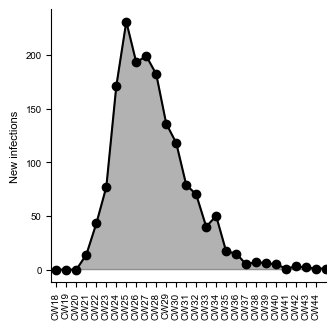

In [9]:
mpox_data = pd.read_csv(path_to_data+"mpox_cases_germany.csv", sep = ";")
fig, ax = plt.subplots(1,1, figsize = [x_size/2, x_size/2])

berlin = np.zeros(len(mpox_data["Berlin"]) + 2)
berlin[2:] = mpox_data["Berlin"]
berlin[np.isnan(berlin)] = 0

print(berlin)
np.save(path_to_parameters+"model/run1/reported_cases.npy",berlin[:26])

ax.plot(berlin, color = "black", marker = 'o')
ax.fill_between(np.linspace(0,len(berlin)-1, len(berlin)), np.zeros(len(berlin)),berlin, color = "black", alpha = 0.3)
ax.set_xlim(-0.5,25+2)
ax.set_ylabel("New infections", **labelfont)
ax.set_xticks(np.linspace(0,24+2, 25+2), ["CW"+str(i) for i in range(18,43+2)], rotation=90)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

1725.0


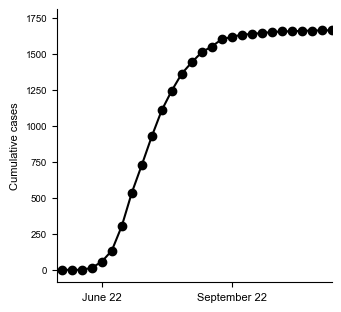

In [10]:
fig, ax = plt.subplots(1,1, figsize = [x_size/2, x_size/2])
ax.plot(np.cumsum(berlin), color = "black", marker = 'o')
ax.set_xlim(-0.5,25+2)
plt.xticks([2+2,15+2], ["June 22","September 22"], **labelfont)
ax.set_ylabel("Cumulative cases", **labelfont)
print(np.cumsum(berlin)[-1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [11]:
# Calculate LL of data given data (perfect fit)

LL_berlin = 0
for i in range(20):
    LL_berlin += np.log(poisson.pmf(berlin[i],berlin[i]))
LL_berlin += np.log(poisson.pmf(np.sum(berlin[20:26]), np.sum(berlin[20:26])))
print(LL_berlin)

-53.249451796807584


In [12]:
# get vaccination numbers
data_kw = np.linspace(18,18+25,26)
data_month = [5,5,5,5,6,6,6,6,7,7,7,7,8,8,8,8,8,9,9,9,9,10,10,10,10,10]
vaccinations = {"5":0, "6":0, "7":4910, "8":3711,"9":3344, "10":3153}
vaccinations_cum = {"5":0, "6":vaccinations["6"], "7":vaccinations["6"]+vaccinations["7"], "8":vaccinations["6"]+vaccinations["7"]+vaccinations["8"],"9":vaccinations["6"]+vaccinations["7"]+vaccinations["8"]+vaccinations["9"], "10":vaccinations["6"]+vaccinations["7"]+vaccinations["8"]+vaccinations["9"]+vaccinations["10"]}

vaccination_timeline = np.zeros(26)

unique, count = np.unique(data_month, return_counts=True)
unique = list(unique)

for i in range(len(vaccination_timeline)):
    month = data_month[i]
    number_weeks = count[unique.index(month)]
    vacc_number = vaccinations[str(month)]
    vaccination_timeline[i] = int(np.floor(vacc_number/number_weeks))

print(vaccination_timeline)
total_vacc = np.sum(vaccination_timeline)
print(total_vacc)

# shift vaccination two weeks, because 14 days is the ramp-up-time https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(23)00057-9/fulltext
vaccination_timeline_effect = np.zeros(26, dtype=int)
vaccination_timeline_effect[2:] = vaccination_timeline[:24]
np.save(path_to_parameters+"model/run1/vaccination_timeline.npy", vaccination_timeline_effect)

print(np.sum(vaccination_timeline_effect))


[   0.    0.    0.    0.    0.    0.    0.    0. 1227. 1227. 1227. 1227.
  742.  742.  742.  742.  742.  836.  836.  836.  836.  630.  630.  630.
  630.  630.]
15112.0
13852


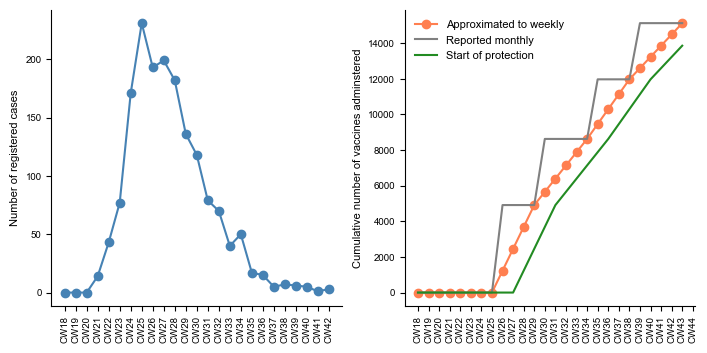

In [17]:
# plot for infection time line and vaccination timeline
fig, ax = plt.subplots(1,2, figsize = [x_size, x_size/2])#[len(cols)*6.4, 4.8])
ax[0].plot(berlin[:25], color = "steelblue", marker = 'o')
ax[0].set_ylabel("Number of registered cases", **labelfont)
ax[0].set_xticks(np.linspace(0,24, 25), ["CW"+str(i) for i in range(18,43)], rotation=90)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].plot(np.cumsum(vaccination_timeline), color = "coral", marker = 'o', label = "Approximated to weekly")
ax[1].set_ylabel("Cumulative number of vaccines adminstered", **labelfont)
vaccination_real = [vaccinations_cum[str(x)] for x in data_month]
ax[1].plot(vaccination_real, color = "grey", label = "Reported monthly")
ax[1].plot(np.cumsum(vaccination_timeline_effect), color = "forestgreen", label = "Start of protection")
ax[1].set_xticks(np.linspace(0,26, 27), ["CW"+str(i) for i in range(18,45)], rotation=90)
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles, labels, frameon=False, prop={'size': legendfont})
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(path_to_plots+"cases_and_vacc.pdf", bbox_inches='tight')
plt.show()

# Intrahost and prudent behaviour dynamics

In [18]:
pop_data = pd.read_csv(path_to_data+"/MPox_final_merged_19062024.csv", sep = ";", encoding='unicode_escape')

print(len(pop_data))
# filter for completion
completed_data = pop_data[pop_data["Result"] == "Completed"].copy()
print(len(completed_data))

print(len(completed_data[completed_data["MPX_DIAGNOSE"] == 1]))
print(len(completed_data[completed_data["MPX_DIAGNOSE"] == 2]))

completed_data.loc[np.isnan(completed_data["SEX_PARTNERS_MALE_ANAL"]), "SEX_PARTNERS_MALE_ANAL"] = 1

# MPX_VERHALTEN_STRONGLY_REDUCED (Anzahl, Orte oder Analverkehr reduziert)
completed_data.loc[:, "MPX_VERHALTEN_STRONGLY_REDUCED"] = (completed_data["MPX_VERHALTEN_1_A1"] == 1) | (completed_data["MPX_VERHALTEN_1_A3"]==1) | (completed_data["MPX_VERHALTEN_1_A4"]==1)#np.where((completed_data["MPX_VERHALTEN_1_A1"] == 1) | (completed_data["MPX_VERHALTEN_1_A3"]==1) | (completed_data["MPX_VERHALTEN_1_A4"]==1), 1, 0)
print(np.sum(completed_data["MPX_VERHALTEN_STRONGLY_REDUCED"])/len(completed_data))

# MPX_VERHALTEN_SOMEWHAT_REDUCED
completed_data.loc[:, "MPX_VERHALTEN_SOMEWHAT_REDUCED"] = ((completed_data["MPX_VERHALTEN_STRONGLY_REDUCED"] == 0)) & ((completed_data["MPX_VERHALTEN_1_A1"] == 2) | (completed_data["MPX_VERHALTEN_1_A3"]==2) | (completed_data["MPX_VERHALTEN_1_A4"]==2))#((completed_data["MPX_VERHALTEN_STRONGLY_REDUCED"] == 0) & np.where((completed_data["MPX_VERHALTEN_1_A1"] == 2) | (completed_data["MPX_VERHALTEN_1_A3"]==2) | (completed_data["MPX_VERHALTEN_1_A4"]==2), 1, 0))
print(np.sum(completed_data["MPX_VERHALTEN_SOMEWHAT_REDUCED"])/len(completed_data))

print(np.sum(completed_data["MPX_VERHALTEN_SOMEWHAT_REDUCED"]) + np.sum(completed_data["MPX_VERHALTEN_STRONGLY_REDUCED"]))
print(len(completed_data[completed_data["MPX_DIAGNOSE"]==1]))

1119
728
47
681
0.2857142857142857
0.12912087912087913
302
47


In [19]:
sliced_data = completed_data[["SEX_PARTNERS_MALE_ANAL", "MPX_VERHALTEN", "MPX_VACC_STATUS_1","MPX_VACC_STATUS_2", "MPX_VERHALTEN_STRONGLY_REDUCED", "MPX_VERHALTEN_SOMEWHAT_REDUCED", "case_yn", "MPX_DIAGNOSE"]].reset_index(drop=True)
print(len(sliced_data))
print(len(sliced_data[np.isnan(sliced_data["SEX_PARTNERS_MALE_ANAL"])]))

print(len(sliced_data[sliced_data["MPX_VACC_STATUS_1"]==3]))
print(len(sliced_data[sliced_data["MPX_VACC_STATUS_1"]==2]))
print(len(sliced_data[sliced_data["MPX_VACC_STATUS_1"]==1]))
sliced_data.loc[sliced_data["MPX_VACC_STATUS_1"]==3, "MPX_VACC_STATUS_1"] = 1

# MPX_VACC_STATUS_1 = 1 means "yes", 2 means "no"
sliced_data.loc[:,"MPX_VACC_STATUS_1"] = (sliced_data["MPX_VACC_STATUS_1"]%2)
print(len(sliced_data[sliced_data["MPX_VACC_STATUS_1"]==0]))
print(len(sliced_data[sliced_data["MPX_VACC_STATUS_1"]==1]))
sliced_data["MPX_VERHALTEN_SOMEWHAT_REDUCED"] = sliced_data["MPX_VERHALTEN_SOMEWHAT_REDUCED"]*1
sliced_data["MPX_VERHALTEN_STRONGLY_REDUCED"] = sliced_data["MPX_VERHALTEN_STRONGLY_REDUCED"]*1
#print(sliced_data.head())

728
0
3
285
440
285
443


In [20]:
# vaccinated are probably over represented in the survey
print("Vaccinated in survey: "+str(len(sliced_data[sliced_data["MPX_VACC_STATUS_1"]==1])/len(sliced_data)))
print("Single vaccinated in survey: "+str(len(sliced_data[sliced_data["MPX_VACC_STATUS_2"]==1])/len(sliced_data)))
print("Double vaccinated in survey: "+str(len(sliced_data[sliced_data["MPX_VACC_STATUS_2"]==2])/len(sliced_data)))
print("Vaccinated in real world (min): "+str(18104/76625))
print("Vaccinated in real world (max): "+str(18104/59394))
print("Double vaccinated in real world (min): "+str(7745/76625))
print("Double vaccinated in real world (min): "+str(7745/59394))

data_vacc = sliced_data[sliced_data["MPX_VACC_STATUS_1"]==1].copy()
data_unvacc = sliced_data[sliced_data["MPX_VACC_STATUS_1"]==0].copy()

values, counts = np.unique(data_vacc["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
counts[np.isnan(counts)] = 0
#plt.scatter(values, counts/np.sum(counts), color = "green")

values, counts = np.unique(data_unvacc["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
counts[np.isnan(counts)] = 0
#plt.scatter(values, counts/np.sum(counts), color = "red")

print(np.mean(data_vacc["SEX_PARTNERS_MALE_ANAL"]))
print(np.mean(data_unvacc["SEX_PARTNERS_MALE_ANAL"]))


Vaccinated in survey: 0.6085164835164835
Single vaccinated in survey: 0.14148351648351648
Double vaccinated in survey: 0.45604395604395603
Vaccinated in real world (min): 0.23626753670473083
Vaccinated in real world (max): 0.3048119338653736
Double vaccinated in real world (min): 0.10107667210440457
Double vaccinated in real world (min): 0.1304003771424723
4.106094808126411
3.0


Vaccinated:
0.1581196581196581
0.04611008006783693
Unvaccinated:
0.2823529411764706
0.03161493565355927


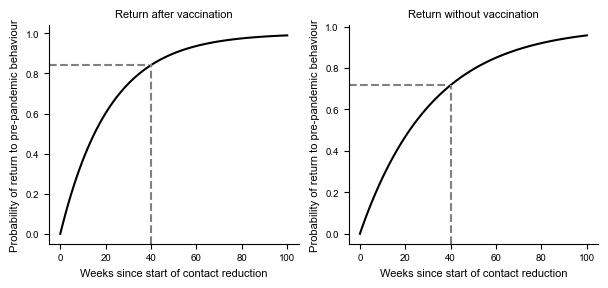

In [21]:
# VACCINATED

print("Vaccinated:")
# Evaluate from yes and yes, not anymore answers how fast the measure is being lifted
active = len(sliced_data[(sliced_data["MPX_VERHALTEN"] == 1) & (sliced_data["MPX_VACC_STATUS_1"] == 1)])
deactivated = len(sliced_data[(sliced_data["MPX_VERHALTEN"] == 2) & (sliced_data["MPX_VACC_STATUS_1"] == 1)])

prob = active/(deactivated+active)
print(prob)

# measure approx. started in mid June 22 and patients answered in mid april 23 -> 10 months inbetween ~ 40 CW
intensity_vacc = -np.log(prob)/40
print(intensity_vacc)

#fig, ax = plt.subplots(1,2, figsize = [2*4, 4])
fig, ax = plt.subplots(1,2, figsize = [x_size, x_size/2.5])
ax[0].plot(np.linspace(0,100,100),1-np.exp(-intensity_vacc * np.linspace(0,100,100)), color = "black")
ax[0].axvline(x=40, ymin= 0, ymax=1-prob-0.02, color = "grey", linestyle = "dashed")
ax[0].axhline(y = 1-prob,xmin = 0, xmax = 0.4, color = "grey", linestyle = "dashed")
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_ylabel("Probability of return to pre-pandemic behaviour", **labelfont)
ax[0].set_xlabel("Weeks since start of contact reduction", **labelfont)
ax[0].set_title("Return after vaccination", **labelfont)



# UNVACCINATED

print("Unvaccinated:")
# Evaluate from yes and yes, not anymore answers how fast the measure is being lifted
active = len(sliced_data[(sliced_data["MPX_VERHALTEN"] == 1) & (sliced_data["MPX_VACC_STATUS_1"] == 0)])
deactivated = len(sliced_data[(sliced_data["MPX_VERHALTEN"] == 2) & (sliced_data["MPX_VACC_STATUS_1"] == 0)])

prob = active/(deactivated+active)
print(prob)

# measure approx. started in mid June 22 and patients answered in mid april 23 -> 10 months inbetween ~ 40 CW
intensity_unvacc = -np.log(prob)/40
print(intensity_unvacc)

ax[1].plot(np.linspace(0,100,100),1-np.exp(-intensity_unvacc * np.linspace(0,100,100)), color = "black")
ax[1].axvline(x=40, ymin= 0, ymax=1-prob+0.01, color = "grey", linestyle = "dashed")
ax[1].axhline(y = 1-prob,xmin = 0, xmax = 0.4, color = "grey", linestyle = "dashed")
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_ylabel("Probability of return to pre-pandemic behaviour", **labelfont)
ax[1].set_xlabel("Weeks since start of contact reduction", **labelfont)
ax[1].set_title("Return without vaccination", **labelfont)

plt.savefig(path_to_plots+"measure_removal.pdf", bbox_inches='tight')
plt.show()

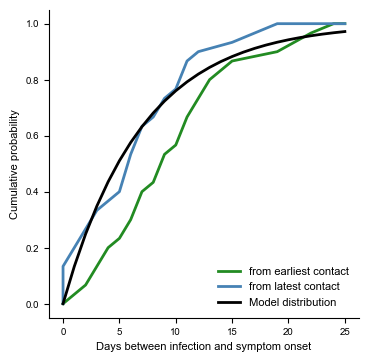

In [39]:
# incubation time 
# Source: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9514338/#SD1
symptom_onset = np.array([8,12,14,15,15,19,20,22,23,23,28,29,29,29,33,37,38,40,42,47,48,49,49,50,51,51,52,54,58,58])
exposure_early = np.array([6,9,2,8,11,11,7,9,18,11,25,27,7,7,9,31,31,21,35,32,42,40,40,46,40,40,41,44,49,44])
exposure_last = np.array([8,12,14,15,14,16,14,14,18,17,25,27,17,14,14,31,31,21,35,46,42,40,40,46,40,40,41,44,56,51])
incubation_upper = symptom_onset - exposure_early
incubation_lower = symptom_onset - exposure_last

values_upper, counts = np.unique(incubation_upper, return_counts=True)
epdf = counts/len(incubation_upper)
ecdf_upper = np.cumsum(epdf)
values_upper = np.insert(values_upper, 0, 0., axis=0)
ecdf_upper = np.insert(ecdf_upper, 0, 0., axis=0)
values_upper = np.insert(values_upper, len(values_upper), 25, axis=0)
ecdf_upper = np.insert(ecdf_upper, len(ecdf_upper), 1, axis=0)

values_lower, counts = np.unique(incubation_lower, return_counts=True)
epdf = counts/len(incubation_lower)
ecdf_lower = np.cumsum(epdf)
values_lower = np.insert(values_lower, 0, 0., axis=0)
ecdf_lower = np.insert(ecdf_lower, 0, 0., axis=0)
values_lower = np.insert(values_lower, len(values_lower), 25, axis=0)
ecdf_lower = np.insert(ecdf_lower, len(ecdf_lower), 1, axis=0)

values = np.linspace(0, max(max(values_upper), max(values_lower)),max(max(values_upper), max(values_lower))+1 )
incubation_rate = 1
incubation_period = 1- np.exp(-incubation_rate/7 * values)

fig, ax = plt.subplots(1,1, figsize = [4, 4])
ax.plot(values_upper, ecdf_upper, color = "forestgreen", label = "from earliest contact", linewidth = 2)
ax.plot(values_lower, ecdf_lower, color = "steelblue", label = "from latest contact", linewidth = 2)
ax.plot(values, incubation_period, color = "black", label = "Model distribution", linewidth = 2)
ax.set_xlabel("Days between infection and symptom onset", **labelfont)
ax.set_ylabel("Cumulative probability", **labelfont)

ax.legend(loc="lower right", frameon=False, prop={'size': legendfont})

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(path_to_plots+"incubation_distribution.pdf", bbox_inches='tight')



5
1.9992262096601519


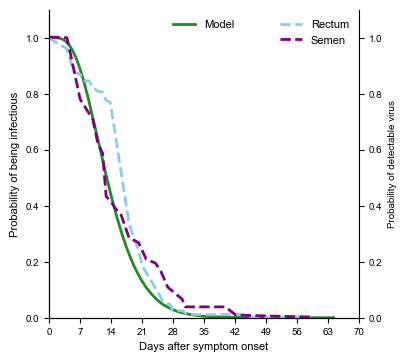

In [37]:
# time between symptom onset and recovery

# could compare to viral shedding data https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(22)00794-0/fulltext#app-1


target_mean = 1/2
number_compartments = 5

intensity_rec = 5/2#target_mean/number_compartments

np.random.rand(7)
data_exp = np.random.exponential(1/intensity_rec,100000)
test = 1
for i in range(number_compartments - 1):
    data_exp += np.random.exponential(1/intensity_rec,100000)
    test += 1
print(test)

mean_infectious = np.mean(data_exp)
print(mean_infectious)

data_exp = np.round(data_exp, 2)


values, counts = np.unique(data_exp, return_counts=True)
epdf = counts/len(data_exp)
ecdf = np.cumsum(epdf)


rectum = pd.read_csv(path_to_data+"other/suner_viral_shedding_rectum.csv")
rectum.loc[-1] = [0, 1] 
rectum.index = rectum.index + 1  # shifting index
rectum.sort_index(inplace=True)

semen = pd.read_csv(path_to_data+"other/suner_viral_shedding_semen.csv")

fig, ax = plt.subplots(1,1, figsize = [4, 4])

ax2 = ax.twinx()
ax.plot(values, 1-ecdf, color = "forestgreen", linewidth = 2, label = "Model")

ax.set_xticks(np.linspace(0,15,16), np.linspace(0,15*7,16).astype(int))
ax.set_xlabel("Days after symptom onset", **labelfont)
ax.set_ylabel("Probability of being infectious", **labelfont)

ax2.set_ylabel("Probability of detectable virus")

ax2.plot(rectum['x']/7, rectum[' y'], color = "skyblue", linestyle = "dashed", linewidth = 2, label = "Rectum")
ax2.plot(semen['x']/7, semen[' y'], color = "purple", linestyle = "dashed", linewidth = 2, label = "Semen")

ax.set_xlim(0,10)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="upper center", frameon=False, ncol = 3, prop={'size': legendfont})
ax2.legend(loc="upper right", frameon=False, prop={'size': legendfont})

ax.set_ylim(0,1.1)
ax2.set_ylim(0,1.1)

plt.savefig(path_to_plots+"infectious_duration.pdf", bbox_inches='tight')

0.9470778505986555
0.9470778505986555


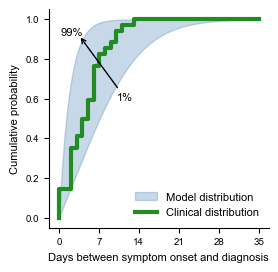

In [24]:
# diagnostic delay 
# Source: https://www.cambridge.org/core/journals/infection-control-and-hospital-epidemiology/article/monkeypox-testing-delays-the-need-for-drastic-expansion-of-education-and-testing-for-monkeypox-virus/72690C69D7FD2C4EC9994AF79D6FDF85

testing_delay = pd.read_csv(path_to_data+"other/sampson_testing_delay.csv")
testing_delay['x'] = testing_delay['x']/7
testing_delay.loc[-1] = [0, 0] 
testing_delay.index = testing_delay.index + 1  # shifting index
testing_delay.sort_index(inplace=True)
testing_delay.loc[-1] = [5, 1] 

def diag_time(x,t, intensity = intensity_rec):
    Q = np.array([[-intensity-x,intensity,0,0,0,0,x],[0,-intensity-x,intensity,0,0,0,x], [0,0,-intensity-x,intensity,0,0,x], [0,0,0,-intensity-x,intensity,0,x], [0,0,0,0,-intensity-x,intensity,x], [0,0,0,0,0,0,0], [0,0,0,0,0,0,0]])
    x_vec = np.array([1, 0,0,0,0,0,0])
    P = np.matmul(x_vec,expm(Q*t))
    return(P[6])

def diag_prop(x, intensity = intensity_rec):
    Q = np.array([[-intensity-x,intensity,0,0,0,0,x],[0,-intensity-x,intensity,0,0,0,x], [0,0,-intensity-x,intensity,0,0,x], [0,0,0,-intensity-x,intensity,0,x], [0,0,0,0,-intensity-x,intensity,x], [0,0,0,0,0,0,0], [0,0,0,0,0,0,0]])
    x = np.array([1,0,0,0,0,0,0])
    P = np.matmul(x,expm(Q*1000))
    return(P[6])
print(diag_time(2, 1000))
print(diag_prop(2))
solution01 = opt.brentq(lambda x: diag_prop(x) - 0.01, 0, 100)
solution99 = opt.brentq(lambda x: diag_prop(x) - 0.99, 0, 100)

x = np.linspace(0, 5, 70)
y01 = np.zeros(len(x))
y99 = np.zeros(len(x))
y = np.zeros(len(x))
for i in range(len(x)):
    y01[i] = diag_time(solution01, x[i])/0.01
    y99[i] = diag_time(solution99, x[i])/0.99

#fig, ax = plt.subplots(1,1, figsize = [4, 4])
fig, ax = plt.subplots(1,1, figsize = [x_size/2.5, x_size/2.5])
ax.fill_between(x, y01, y99, color = "steelblue", alpha = 0.3, label = "Model distribution")

ax.step(testing_delay['x'], testing_delay[' y'], color = 'forestgreen', linewidth=3, label = "Clinical distribution")


ax.set_xticks(np.linspace(0,5,6), [0,7,14,21,28,35])
ax.set_xlabel("Days between symptom onset and diagnosis", **labelfont)
ax.set_ylabel("Cumulative probability", **labelfont)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="lower right", frameon=False, prop={'size': legendfont})

ax.annotate('1%', xy =(0.5, 0.92), xytext =(1.45, 0.59), arrowprops = dict(facecolor ='black', arrowstyle = "->"), **labelfont)
ax.annotate('99%', xy =(0.3, 0.6), xytext =(0.03, 0.92), **labelfont)

plt.savefig(path_to_plots+"diagnosis_delay.pdf", bbox_inches='tight')


In [25]:
# Save population independet parameters of model
data = {'incubation_rate': [incubation_rate],
    'recovery_rate': [intensity_rec],
    'number_infectious_compartments': [number_compartments],
    'return_vacc': [intensity_vacc],
    'return_unvacc': [intensity_unvacc]}

# Create DataFrame
diseases_parameters = pd.DataFrame(data)
diseases_parameters.to_csv(path_to_parameters+"model/run1/diseases_parameters.csv", index=False)

print(diseases_parameters)


   incubation_rate  recovery_rate  number_infectious_compartments  \
0                1            2.5                               5   

   return_vacc  return_unvacc  
0      0.04611       0.031615  


# Population analysis

In [26]:
print("HIV prevalence in Study: "+str(len(completed_data[completed_data["HIV_DIAGNOSIS"]==1])/len(completed_data)))
print("HIV prevalence in EMIS: 0.195")
print("PrEP intake in Study: "+ str(len(completed_data[completed_data["PREP"]>1])/len(completed_data)))

HIV prevalence in Study: 0.15796703296703296
HIV prevalence in EMIS: 0.195
PrEP intake in Study: 0.5508241758241759


In [27]:
def contacts_at_risk(data, col, col1, seed = 2, reps = 1):
    tmp = []
    np.random.seed(seed)
    for i in range(len(data)):
        if data.iloc[i][col] == 6:
            tmp.append(np.random.randint(5,8))
        elif data.iloc[i][col] == 7:
            tmp.append(np.random.randint(8,11))
        elif data.iloc[i][col] == 8:
            tmp.append(np.random.randint(11,21))
        elif data.iloc[i][col] == 9:
            tmp.append(np.random.randint(21,31))
        elif data.iloc[i][col] == 10:
            tmp.append(np.random.randint(31,41))
        elif data.iloc[i][col] == 11:
            tmp.append(np.random.randint(41,51))
        elif data.iloc[i][col] == 12:
            tmp.append(np.random.randint(51,60))
        elif np.isnan(data.iloc[i][col]) == True:
            tmp.append([0 for x in range(reps)])
        else:
            tmp.append(data.iloc[i][col] -1)

    data["sampled_partners"] = tmp

    total_contacts = np.sum(tmp)
    contacts_at_risk = np.sum(data[data[col1] == 1]["sampled_partners"])

    print(contacts_at_risk/total_contacts)

contacts_at_risk(sliced_data, "SEX_PARTNERS_MALE_ANAL", "MPX_VERHALTEN_STRONGLY_REDUCED")
contacts_at_risk(sliced_data, "SEX_PARTNERS_MALE_ANAL", "MPX_VERHALTEN_SOMEWHAT_REDUCED")

0.27180101887923286
0.1908900209769254


443
285
0.05869074492099323
0.23859649122807017
4.106094808126411
6.916509128708936
3.0
5.670175438596491


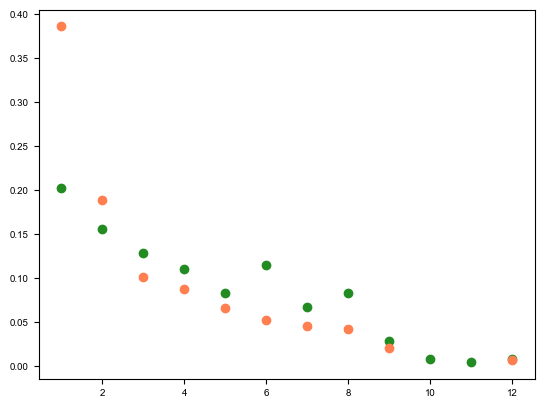

In [28]:
# partition population into vaccinated and unvaccinated
pop_vacc = sliced_data[sliced_data["MPX_VACC_STATUS_1"] == 1]
pop_unvacc = sliced_data[sliced_data["MPX_VACC_STATUS_1"] == 0]

print(len(pop_vacc))
print(len(pop_unvacc))

print(np.mean(pop_vacc["case_yn"]))
print(np.mean(pop_unvacc["case_yn"]))

# degree per vaccination
col = "SEX_PARTNERS_MALE_ANAL"
values, count = np.unique(pop_vacc[col], return_counts=True)
print(np.mean(pop_vacc[col]))
print(np.var(pop_vacc[col]))
plt.scatter(values, count/np.sum(count), color = "forestgreen")

values, count = np.unique(pop_unvacc[col], return_counts=True)
print(np.mean(pop_unvacc[col]))
print(np.var(pop_unvacc[col]))
plt.scatter(values, count/np.sum(count), color = "coral")
plt.show()


R² = 0.9852181954404055
Y = 0.20471246643097335 * e^(-0.2534986275866561 * x) + 0.0009999999999982117


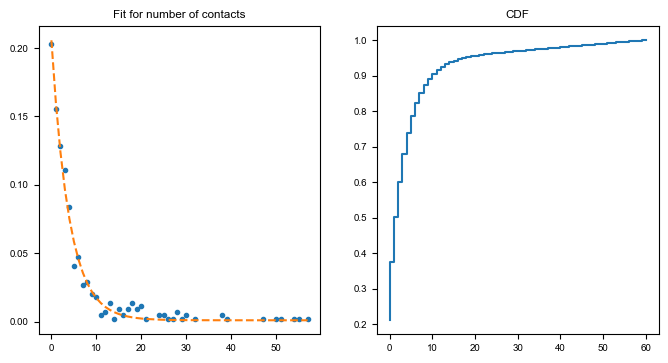

In [29]:
cdf_vacc = fit_monoExpb(np.array(pop_vacc["SEX_PARTNERS_MALE_ANAL"]), upper_bound = 0.001, reps = 1)
plt.savefig(path_to_plots+"/population_vacc.pdf", bbox_inches='tight')

R² = 0.9806262384822462
Y = 0.37317456383825254 * e^(-0.566980245526451 * x) + 0.0004999999999999999


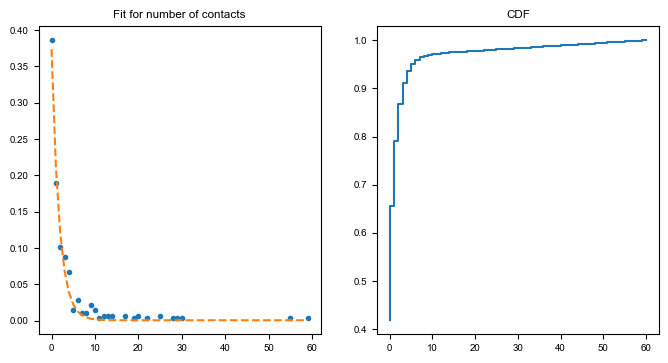

In [30]:
cdf_unvacc = fit_monoExpb(np.array(pop_unvacc["SEX_PARTNERS_MALE_ANAL"]), upper_bound = 0.0005, reps = 1)
plt.savefig(path_to_plots+"/population_unvacc.pdf", bbox_inches='tight')

In [32]:
# contact reduction per vaccination and degree
col = "SEX_PARTNERS_MALE_ANAL"
col2 = "MPX_VERHALTEN_STRONGLY_REDUCED"

contact_red_vacc = get_contact_reduction(pop_vacc, col, col2)
print(contact_red_vacc)

contact_red_unvacc = get_contact_reduction(pop_unvacc, col, col2)
print(contact_red_unvacc)

[0.33333333 0.26086957 0.33333333 0.36734694 0.64864865 0.45098039
 0.4        0.27027027 0.30769231 0.25       0.         0.        ]
[0.11818182 0.12962963 0.20689655 0.32       0.42105263 0.06666667
 0.23076923 0.16666667 0.16666667        nan        nan 0.        ]


In [33]:
# sample case prediction
col = "SEX_PARTNERS_MALE_ANAL"
col2 = "case_yn"

case_vacc = get_contact_reduction(pop_vacc, col, col2)
print(contact_red_vacc)

case_unvacc = get_contact_reduction(pop_unvacc, col, col2)
print(contact_red_unvacc)

[0.33333333 0.26086957 0.33333333 0.36734694 0.64864865 0.45098039
 0.4        0.27027027 0.30769231 0.25       0.         0.        ]
[0.11818182 0.12962963 0.20689655 0.32       0.42105263 0.06666667
 0.23076923 0.16666667 0.16666667        nan        nan 0.        ]


In [34]:
# degree to codes dict
degree_to_code = {}
degree_to_code[0] = 1
degree_to_code[1] = 2
degree_to_code[2] = 3
degree_to_code[3] = 4
degree_to_code[4] = 5
degree_to_code[5] = 6
degree_to_code[6] = 6
degree_to_code[7] = 6
degree_to_code[8] = 7
degree_to_code[9] = 7
degree_to_code[10] = 7
for i in range(1,11):
    degree_to_code[10+i] = 8
    degree_to_code[20+i] = 9
    degree_to_code[30+i] = 10
    degree_to_code[40+i] = 11
    degree_to_code[50+i] = 12

print(degree_to_code)

dic_coded = {'2':[1],
             '3':[2],
             '4':[3],
             '5':[4],
             '6':[5,6,7],
             '7':[8,9,10],
             '8':[11,12,13,14,15,16,17,18,19,20],
             '9':[21,22,23,24,25,26,27,28,29,30],
             '10':[31,32,33,34,35,36,37,38,39,40],
             '11':[41,42,43,44,45,46,47,48,49,50],
             '12':[51,52,53,54,55,56,57,58,59,50]}

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 6, 7: 6, 8: 7, 9: 7, 10: 7, 11: 8, 21: 9, 31: 10, 41: 11, 51: 12, 12: 8, 22: 9, 32: 10, 42: 11, 52: 12, 13: 8, 23: 9, 33: 10, 43: 11, 53: 12, 14: 8, 24: 9, 34: 10, 44: 11, 54: 12, 15: 8, 25: 9, 35: 10, 45: 11, 55: 12, 16: 8, 26: 9, 36: 10, 46: 11, 56: 12, 17: 8, 27: 9, 37: 10, 47: 11, 57: 12, 18: 8, 28: 9, 38: 10, 48: 11, 58: 12, 19: 8, 29: 9, 39: 10, 49: 11, 59: 12, 20: 8, 30: 9, 40: 10, 50: 11, 60: 12}


# Population sampling (new)

In [35]:
N = 59394
N_vacc = 18104

sampled_pop = pd.DataFrame(columns=["SEX_PARTNERS_MALE_ANAL", "SEX_PARTNERS_MALE_ANAL_UNCODED", "MPX_VACC_STATUS_1", "MPX_VERHALTEN_STRONGLY_REDUCED", "MPX_VERHALTEN_SOMEWHAT_REDUCED", "case_yn", "1year_contacts"])

print(sampled_pop)

np.random.seed(1)
for k in range(N_vacc):
    # sample degree
    u = np.random.rand()
    degree = np.searchsorted(cdf_vacc, u, side="left")
    # degree to code
    code = degree_to_code[degree]
    # sample behaviour change given degree and vacc status
    u = np.random.rand()
    behaviour_change = 1 if u < contact_red_vacc[code-1] else 0
    # sample case prediction 
    u = np.random.rand()
    case = 1 if u < case_vacc[code-1] else 0
    # sample contacts in 1 year (only for EMIS)
    one_year = np.random.poisson(degree * 4)
    # put it all together
    sampled_pop.loc[k] = [code, degree, 1, behaviour_change, 0, case, one_year]

for l in range(N - N_vacc):
    # sample degree
    u = np.random.rand()
    degree = np.searchsorted(cdf_unvacc, u, side="left")
    # degree to code
    code = degree_to_code[degree]
    # sample behaviour change given degree and vacc status
    u = np.random.rand()
    behaviour_change = 1 if u < contact_red_unvacc[code-1] else 0
    # sample case prediction 
    u = np.random.rand()
    case = 1 if u < case_unvacc[code-1] else 0
    # sample contacts in 1 year (only for EMIS)
    one_year = np.random.poisson(degree * 4)
    # put it all together
    sampled_pop.loc[k+l+1] = [code, degree, 0, behaviour_change, 0, case, one_year]


print(sampled_pop)

Empty DataFrame
Columns: [SEX_PARTNERS_MALE_ANAL, SEX_PARTNERS_MALE_ANAL_UNCODED, MPX_VACC_STATUS_1, MPX_VERHALTEN_STRONGLY_REDUCED, MPX_VERHALTEN_SOMEWHAT_REDUCED, case_yn, 1year_contacts]
Index: []
       SEX_PARTNERS_MALE_ANAL  SEX_PARTNERS_MALE_ANAL_UNCODED  \
0                           3                               2   
1                           3                               2   
2                           1                               0   
3                           2                               1   
4                           1                               0   
...                       ...                             ...   
59389                       3                               2   
59390                       3                               2   
59391                       1                               0   
59392                       5                               4   
59393                       1                               0   

       MPX_VACC_STA

In [40]:
print(np.sum(sampled_pop["case_yn"]))
print(np.sum(sampled_pop[sampled_pop["MPX_VERHALTEN_STRONGLY_REDUCED"] == 1]["SEX_PARTNERS_MALE_ANAL_UNCODED"])/np.sum(sampled_pop["SEX_PARTNERS_MALE_ANAL_UNCODED"]))

8482
0.21626266376703973


[21150 12797  7954  4958  3132  2055  1420  1026   711   526   396   308
   226   196   166   140   115    98    89    85    66    57    66    51
    60    58    43    36    32    51    47    44    34    48    46    35
    47    35    37    38    47    48    42    45    38    34    58    47
    41    43    43    44    39    39    48    40    43    54    41    44
    37]


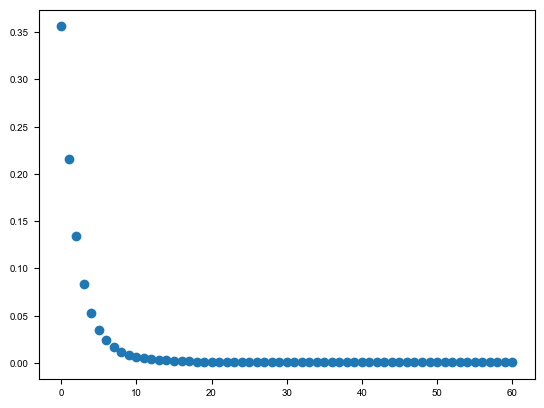

In [41]:
values, counts = np.unique(sampled_pop["SEX_PARTNERS_MALE_ANAL_UNCODED"], return_counts=True)
plt.scatter(values, counts/np.sum(counts))
print(counts)

In [42]:
sampled_pop_active = sampled_pop[sampled_pop["SEX_PARTNERS_MALE_ANAL_UNCODED"] > 0].copy()
mu_vec_plot = sampled_pop["SEX_PARTNERS_MALE_ANAL_UNCODED"]
mu_vec = sampled_pop_active["SEX_PARTNERS_MALE_ANAL_UNCODED"]
print(len(sampled_pop_active))
vaccinations_outside_network = np.sum(sampled_pop[sampled_pop["SEX_PARTNERS_MALE_ANAL_UNCODED"] == 0]["MPX_VACC_STATUS_1"])
vaccinations_in_network = np.sum(sampled_pop[sampled_pop["SEX_PARTNERS_MALE_ANAL_UNCODED"] > 0]["MPX_VACC_STATUS_1"])
print(vaccinations_outside_network)
print(vaccinations_outside_network + vaccinations_in_network)

38244
3894
18104


5
2.00244775318064


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2629921211.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


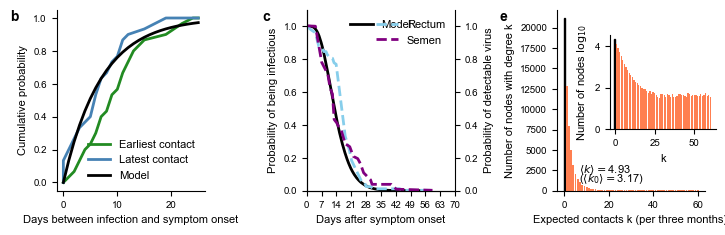

In [43]:
# figure 1
fig = plt.figure(figsize=(x_size, x_size/3))

# left
# distribution of incubation time
ax = fig.add_subplot(1,3,1)

# Source: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9514338/#SD1
symptom_onset = np.array([8,12,14,15,15,19,20,22,23,23,28,29,29,29,33,37,38,40,42,47,48,49,49,50,51,51,52,54,58,58])
exposure_early = np.array([6,9,2,8,11,11,7,9,18,11,25,27,7,7,9,31,31,21,35,32,42,40,40,46,40,40,41,44,49,44])
exposure_last = np.array([8,12,14,15,14,16,14,14,18,17,25,27,17,14,14,31,31,21,35,46,42,40,40,46,40,40,41,44,56,51])
incubation_upper = symptom_onset - exposure_early
incubation_lower = symptom_onset - exposure_last

values_upper, counts = np.unique(incubation_upper, return_counts=True)
epdf = counts/len(incubation_upper)
ecdf_upper = np.cumsum(epdf)
values_upper = np.insert(values_upper, 0, 0., axis=0)
ecdf_upper = np.insert(ecdf_upper, 0, 0., axis=0)
values_upper = np.insert(values_upper, len(values_upper), 25, axis=0)
ecdf_upper = np.insert(ecdf_upper, len(ecdf_upper), 1, axis=0)

values_lower, counts = np.unique(incubation_lower, return_counts=True)
epdf = counts/len(incubation_lower)
ecdf_lower = np.cumsum(epdf)
values_lower = np.insert(values_lower, 0, 0., axis=0)
ecdf_lower = np.insert(ecdf_lower, 0, 0., axis=0)
values_lower = np.insert(values_lower, len(values_lower), 25, axis=0)
ecdf_lower = np.insert(ecdf_lower, len(ecdf_lower), 1, axis=0)

values = np.linspace(0, max(max(values_upper), max(values_lower)),max(max(values_upper), max(values_lower))+1 )
incubation_rate = 1
incubation_period = 1- np.exp(-incubation_rate/7 * values)

ax.plot(values_upper, ecdf_upper, color = "forestgreen", label = "Earliest contact", linewidth = 2)
ax.plot(values_lower, ecdf_lower, color = "steelblue", label = "Latest contact", linewidth = 2)
ax.plot(values, incubation_period, color = "black", label = "Model", linewidth = 2)
ax.set_xlabel("Days between infection and symptom onset", **labelfont)
ax.set_ylabel("Cumulative probability", **labelfont)

ax.legend(loc="lower right", frameon=False, prop={'size': legendfont})

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# middle
# distribution of infectious period
ax = fig.add_subplot(1,3,2)

# could compare to viral shedding data https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(22)00794-0/fulltext#app-1
target_mean = 1/2
number_compartments = 5

intensity_rec = 5/2#target_mean/number_compartments

np.random.seed(7)
data_exp = np.random.exponential(1/intensity_rec,100000)
test = 1
for i in range(number_compartments - 1):
    data_exp += np.random.exponential(1/intensity_rec,100000)
    test += 1
print(test)

mean_infectious = np.mean(data_exp)
print(mean_infectious)
data_exp = np.round(data_exp, 2)

values, counts = np.unique(data_exp, return_counts=True)
epdf = counts/len(data_exp)
ecdf = np.cumsum(epdf)

rectum = pd.read_csv(path_to_data+"other/suner_viral_shedding_rectum.csv")
rectum.loc[-1] = [0, 1] 
rectum.index = rectum.index + 1  # shifting index
rectum.sort_index(inplace=True)

semen = pd.read_csv(path_to_data+"other/suner_viral_shedding_semen.csv")
ax2 = ax.twinx()
ax.plot(values, 1-ecdf, color = "black", linewidth = 2, label = "Model")

ax.set_xticks(np.linspace(0,15,16), np.linspace(0,15*7,16).astype(int))
ax.set_xlabel("Days after symptom onset", **labelfont)
ax.set_ylabel("Probability of being infectious", **labelfont)

ax2.set_ylabel("Probability of detectable virus", **labelfont)

ax2.plot(rectum['x']/7, rectum[' y'], color = "skyblue", linestyle = "dashed", linewidth = 2, label = "Rectum")
ax2.plot(semen['x']/7, semen[' y'], color = "purple", linestyle = "dashed", linewidth = 2, label = "Semen")

ax.set_xlim(0,10)

ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="upper center", frameon=False, ncol = 3, prop={'size': legendfont})
ax2.legend(loc="upper right", frameon=False,prop={'size': legendfont})

ax.set_ylim(0,1.1)
ax2.set_ylim(0,1.1)



# right panel
# distribution of expected contacts
ax1 = fig.add_subplot(1,3,3)
left, bottom, width, height = [0.85, 0.45, 0.15, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
values, counts = np.unique(mu_vec_plot, return_counts=True)
ax1.bar(values[0], (counts[0]), color = "white", edgecolor = "black", width = 0.66)
ax1.bar(values[1:], (counts[1:]), color = "coral")
ax1.annotate(r'$\langle k \rangle =$'+str(np.round(np.mean(mu_vec),2)), xy = (0.15,0.1), xycoords='axes fraction', **labelfont)
ax1.annotate(r'($\langle k_0 \rangle =$'+str(np.round(np.sum(mu_vec_plot)/N,2))+")", xy = (0.15,0.05), xycoords='axes fraction', **labelfont)
ax1.set_xlabel("Expected contacts k (per three months) ", **labelfont)
ax1.set_ylabel('Number of nodes with degree k', **labelfont)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.bar(values[0], np.log10(counts[0]), color = "white", edgecolor = "black", width = 0.66)
ax2.bar(values[1:], np.log10(counts[1:]), color = "coral")
ax2.set_xlabel("k", **labelfont)
ax2.set_ylabel(r'Number of nodes $\log_{10}$', **labelfont)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


fig.tight_layout()

# cosmetics
ax1.text(-2,1,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax2.text(-0.3,1,
           'c',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(1.3,1,
           'e',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )



plt.savefig(path_to_plots+"/figure1.svg", bbox_inches='tight')

0.4079536653534027


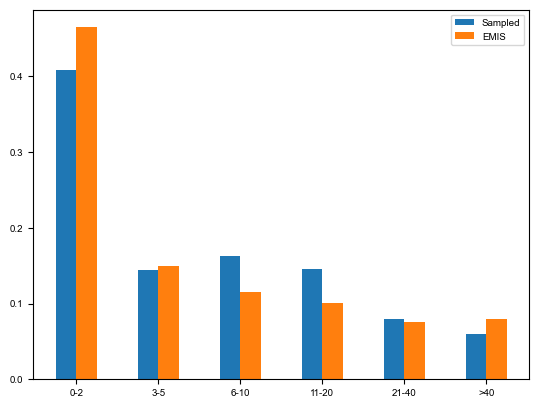

In [44]:
values, counts = np.unique(sampled_pop["1year_contacts"], return_counts=True)

frequency_sampled = [np.sum(counts[[0,1,2]])/np.sum(counts),np.sum(counts[[3,4,5]])/np.sum(counts),np.sum(counts[[6,7,8,9,10]])/np.sum(counts),np.sum(counts[[11,12,13,14,15,16,17,18,19,20]])/np.sum(counts),np.sum(counts[21:40])/np.sum(counts),np.sum(counts[40:])/np.sum(counts)]

print(np.sum(counts[[0,1,2]])/np.sum(counts))

categories = ["0-2", "3-5", "6-10", "11-20", "21-40", ">40"]
frequency_emis = [0.4647,	0.1491,	0.1146,	0.1013,	0.0755,	0.0792]

barWidth = 0.25
br1 = np.arange(len(frequency_sampled))
br2 = [x+barWidth for x in br1]

plt.bar(br1, frequency_sampled, label = "Sampled", width = barWidth)
plt.bar(br2, frequency_emis, label = 'EMIS', width = barWidth)
plt.xticks([r+barWidth/2 for r in range(len(frequency_sampled))], categories)
plt.legend()

In [45]:
# time scale of model is kalender week
# contacts are reported per 3 months, which are 12 kalender weeks
mu = sampled_pop_active["SEX_PARTNERS_MALE_ANAL_UNCODED"].values
lambda_plus = get_rates(mu)/np.sqrt(12)
print(mu)
print(np.sum(mu/12)/2)
print(lambda_plus)

[2 2 1 ... 2 2 4]
7855.416666666667
[0.00132905 0.00132905 0.00066449 ... 0.00132905 0.00132905 0.00265841]


In [46]:
# Warning: RAM required
Q = np.matmul(lambda_plus.reshape((len(lambda_plus), 1)),lambda_plus.reshape(1,len(lambda_plus)))
np.fill_diagonal(Q, 0)
print(Q)
P = 1 - np.exp(-Q*12)
print(P)
print(np.sum(P, axis = 1))
print(np.sum(np.sum(P, axis = 1)-mu))
del P, Q

[[0.00000000e+00 1.76637358e-06 8.83134680e-07 ... 1.76637358e-06
  1.76637358e-06 3.53316409e-06]
 [1.76637358e-06 0.00000000e+00 8.83134680e-07 ... 1.76637358e-06
  1.76637358e-06 3.53316409e-06]
 [8.83134680e-07 8.83134680e-07 0.00000000e+00 ... 8.83134680e-07
  8.83134680e-07 1.76647782e-06]
 ...
 [1.76637358e-06 1.76637358e-06 8.83134680e-07 ... 0.00000000e+00
  1.76637358e-06 3.53316409e-06]
 [1.76637358e-06 1.76637358e-06 8.83134680e-07 ... 1.76637358e-06
  0.00000000e+00 3.53316409e-06]
 [3.53316409e-06 3.53316409e-06 1.76647782e-06 ... 3.53316409e-06
  3.53316409e-06 0.00000000e+00]]
[[0.00000000e+00 2.11962583e-05 1.05975600e-05 ... 2.11962583e-05
  2.11962583e-05 4.23970703e-05]
 [2.11962583e-05 0.00000000e+00 1.05975600e-05 ... 2.11962583e-05
  2.11962583e-05 4.23970703e-05]
 [1.05975600e-05 1.05975600e-05 0.00000000e+00 ... 1.05975600e-05
  1.05975600e-05 2.11975091e-05]
 ...
 [2.11962583e-05 2.11962583e-05 1.05975600e-05 ... 0.00000000e+00
  2.11962583e-05 4.23970703e-05]

In [47]:
# Warning: RAM required
Q = np.matmul(lambda_plus.reshape((len(lambda_plus), 1)),lambda_plus.reshape(1,len(lambda_plus)))
np.fill_diagonal(Q, 0)
print("Q done")
P = 1 - np.exp(-Q)
print("P done")
mu_1 =np.sum(P, axis = 1) 
print(mu_1)
print(np.sum(mu_1))
del P, Q

Q done
P done
[0.16668308 0.16668308 0.08333744 ... 0.16668308 0.16668308 0.33339898]
15726.475843220862


In [48]:
# approximation rule
r2_error = 0
for i in range(len(lambda_plus)):
    r2_error += (np.sum(lambda_plus[i] * lambda_plus)- lambda_plus[i]**2 - mu_1[i])**2
print(r2_error)

0.0009894520224140205


In [49]:
# set mu_1 to approximation
for i in range(len(lambda_plus)):
    mu_1[i] = np.sum(lambda_plus[i] * lambda_plus)- lambda_plus[i]**2
print(np.sum(mu_1)/2)
print((np.sum(lambda_plus)**2- np.sum(lambda_plus**2))/2)

sampled_pop_active.loc[:,"lambda_plus"] = lambda_plus
sampled_pop_active.loc[:,"lambda_minus"] = np.ones(len(lambda_plus))
sampled_pop_active.loc[:,"mu_1"] = mu_1

7863.950904049778
7863.950904049778


In [50]:
sampled_pop_active.drop(["SEX_PARTNERS_MALE_ANAL", "1year_contacts"], axis=1).to_csv(path_to_parameters+"alternatives/low_behaviour_change/run1/population.csv", index=False)
sampled_pop_active.head()

,SEX_PARTNERS_MALE_ANAL,SEX_PARTNERS_MALE_ANAL_UNCODED,MPX_VACC_STATUS_1,MPX_VERHALTEN_STRONGLY_REDUCED,MPX_VERHALTEN_SOMEWHAT_REDUCED,case_yn,1year_contacts,lambda_plus,lambda_minus,mu_1
0,3,2,1,0,0,1,4,0.001329,1.0,0.166685
1,3,2,1,0,0,0,7,0.001329,1.0,0.166685
3,2,1,1,0,0,0,2,0.000664,1.0,0.083338
5,3,2,1,0,0,0,9,0.001329,1.0,0.166685
7,2,1,1,0,0,0,1,0.000664,1.0,0.083338


In [51]:
np.sum(sampled_pop_active["SEX_PARTNERS_MALE_ANAL_UNCODED"])
print(np.sum(sampled_pop_active["MPX_VACC_STATUS_1"]))
print(np.sum(sampled_pop_active["MPX_VERHALTEN_SOMEWHAT_REDUCED"])/N)
print(np.sum(sampled_pop_active["MPX_VERHALTEN_STRONGLY_REDUCED"])/N)

14210
0.0
0.16464626056504025


Index(['SEX_PARTNERS_MALE_ANAL', 'SEX_PARTNERS_MALE_ANAL_UNCODED',
       'MPX_VACC_STATUS_1', 'MPX_VERHALTEN_STRONGLY_REDUCED',
       'MPX_VERHALTEN_SOMEWHAT_REDUCED', 'case_yn', '1year_contacts'],
      dtype='object')
   SEX_PARTNERS_MALE_ANAL  SEX_PARTNERS_MALE_ANAL_UNCODED  MPX_VACC_STATUS_1  \
0                       3                               2                  1   
1                       3                               2                  1   
3                       2                               1                  1   
5                       3                               2                  1   
7                       2                               1                  1   

   MPX_VERHALTEN_STRONGLY_REDUCED  MPX_VERHALTEN_SOMEWHAT_REDUCED  case_yn  \
0                               0                             0.0        1   
1                               0                             0.0        0   
3                               0                             1

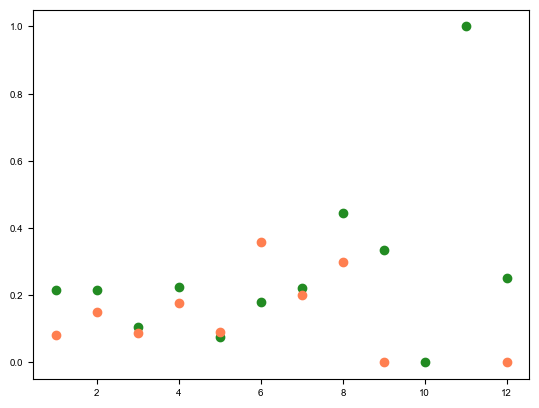

In [52]:
# extra sample for high behaviour change run:
# sample "behaviour change somewhat"

# P(somewhat| degree + vaccination + no strong change)

col = "SEX_PARTNERS_MALE_ANAL"
col2 = "MPX_VERHALTEN_SOMEWHAT_REDUCED"

pop_vacc_nostrong = pop_vacc[pop_vacc["MPX_VERHALTEN_STRONGLY_REDUCED"] == 0]
pop_unvacc_nostrong = pop_unvacc[pop_unvacc["MPX_VERHALTEN_STRONGLY_REDUCED"] == 0]

somewhat_vacc = get_contact_reduction(pop_vacc_nostrong, col, col2)

somewhat_unvacc = get_contact_reduction(pop_unvacc_nostrong, col, col2)

plt.scatter(np.linspace(1,12,12),somewhat_vacc, color = "forestgreen")
plt.scatter(np.linspace(1,12,12),somewhat_unvacc, color = "coral")

# add the somewhat reduction and save 
tmp = np.zeros(len(sampled_pop_active))

print(sampled_pop.columns)

np.random.seed(1)
for i in range(len(tmp)):
    if sampled_pop_active.iloc[i]["MPX_VERHALTEN_STRONGLY_REDUCED"] == 0:
        u = np.random.rand()
        if sampled_pop_active.iloc[i]["MPX_VACC_STATUS_1"] == 1:
            tmp[i] = 1 if u < somewhat_vacc[code-1] else 0
        else:
            tmp[i] = 1 if u < somewhat_unvacc[code-1] else 0

sampled_pop_active["MPX_VERHALTEN_SOMEWHAT_REDUCED"] = tmp

print(sampled_pop_active.head())

sampled_pop_active.drop(["SEX_PARTNERS_MALE_ANAL", "1year_contacts"], axis=1).to_csv(path_to_parameters+"model/run1/population.csv", index=False)


# Model calibration

# Run 1

In [45]:
np.random.seed(1)


inf_prob_all = np.round(np.linspace(0.01,0.99,99), 2)
diag_prob_all = np.round(np.linspace(0.24,0.42,16), 2)
i0_all = [5,6,7,8,9,10,11,12,13,14,15]
behaviour_change_all = np.round(np.linspace(0.1,0.9,9), 2)
behaviour_change_rate_all = [0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])
i = 0

number_samples = 100000

for i in range(number_samples):
    inf_prob = np.random.choice(inf_prob_all)
    diag_prob = np.random.choice(diag_prob_all)
    i0 = np.random.choice(i0_all)
    behaviour_change = np.random.choice(behaviour_change_all)
    behaviour_change_rate = np.random.choice(behaviour_change_rate_all)

    df.loc[i] = [inf_prob, diag_prob, i0, behaviour_change, behaviour_change_rate]

df.to_csv(path_to_parameters+"model/run1/sampled_parameters.csv", index=False)
print(len(df))
df.head()

100000


,inf_rate,diag_prob,i0,behaviour_change,behaviour_change_rate
0,0.38,0.37,13.0,0.6,0.00005
1,0.17,0.25,12.0,0.7,0.00050
2,0.21,0.41,10.0,0.3,0.00500
3,0.12,0.38,15.0,0.3,0.00500
4,0.88,0.32,14.0,0.2,0.10000


In [7]:
repo = path_to_results+ "model/run1"
#combine_results(repo)
multiple = 8
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)

518


# Run 2 

In [8]:
df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/100)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df.to_csv(path_to_parameters+"model/run2/sampled_parameters.csv", index=False)


In [9]:
repo = path_to_results+"model/run2"
#combine_results(repo)
multiple = 5
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)


2453


# Run 3

In [ ]:
df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

k = 0
for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4], p = [0.01, 0.01,0.3, 0.35, 0.3, 0.01,0.01,0.01])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/10)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df = pd.concat([df, df, df, df, df])
df.to_csv(path_to_parameters+"model/run3/sampled_parameters.csv", index=False)


In [85]:
repo = path_to_results+"model/run3"
#combine_results(repo, 5000)
#partition_large_files(repo)

multiple = 3
LL_range_D, LL_range_I, LL_range_lambda, LL_range_R, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll_large(repo, multiple, LL_berlin)
LL_model = LL_range_D["LL"].values


100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
143


/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=

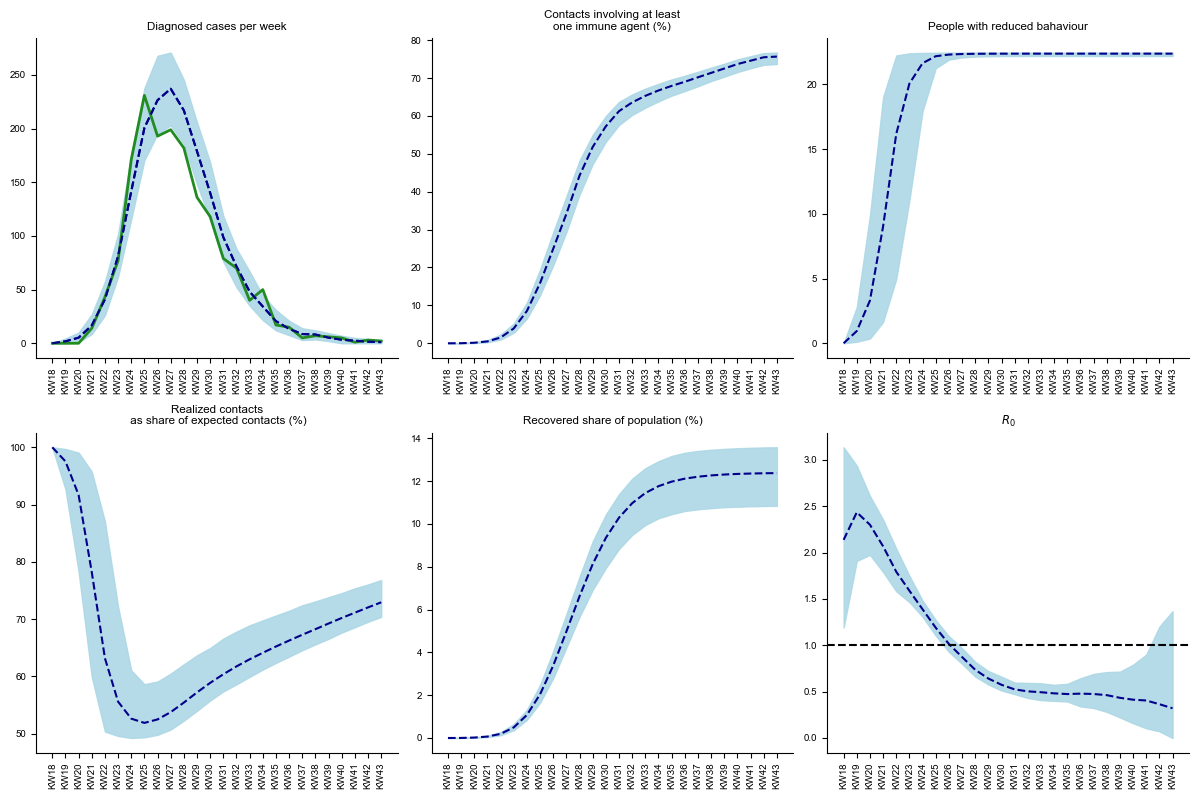

In [54]:
fig = plot_timelines(LL_range_D, LL_range_R, LL_range_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_R_lambda, N, mean_infectious, berlin)

plt.tight_layout()
plt.savefig(path_to_plots+"result_timelines.pdf", bbox_inches='tight')
plt.show()

inf_prob
0.6835206458916344
0.6501465612036382
0.7039744376066264
diag_prob
0.25026304696416607
0.22959015790659235
0.28958555826930027
i0
14.132867132867133
10.0
18.44999999999999
Recovered
12.375128659601838
10.844698117654982
13.580580530019867
30.924999999999997
Diagnosed
3.038120918714918
2.815183351853723
3.2687645216688552
Immunized
37.409914730856244
36.426827625686094
38.15351719028858
Contact reduced
22.368403391739083
22.184900831733845
22.451762804323668


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/559211307.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/559211307.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/559211307.py:73: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/i

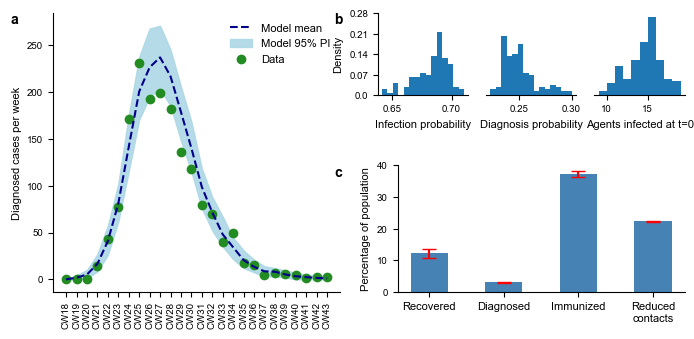

In [55]:
# Figure 2
fig = plt.figure(figsize=(x_size*1.15, y_size/3))

# left panel
# model fit
t = np.linspace(0,25,26)
ax = fig.add_subplot(1,2,1)
ax.plot(np.mean(LL_range_D, axis = 0)[5:31], color = "darkblue", linestyle = "dashed", label = "Model mean")
ax.fill_between(t,LL_range_D.quantile(0.025)[5:31], LL_range_D.quantile(0.975)[5:31], color = "lightblue", alpha = 0.9, label = "Model 95% PI")
ax.set_xticks(t, ["CW"+str(i) for i in range(18,44)], rotation=90)
#ax.plot(berlin[:26], color = "forestgreen", linewidth = 2, label = "Data")
ax.scatter(t, berlin[:26], color = "forestgreen", label = "Data")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Diagnosed cases per week", **labelfont)
ax.legend(frameon=False,prop={'size': legendfont})

# upper right panel
# posterior distributions

columns = ["inf_prob", "diag_prob", "i0"]
bins = [15,15,10]
titles = ["Infection probability", "Diagnosis probability", "Agents infected at t=0"]
i=0
for col in columns:
    #ax = fig.add_subplot(3,12,8+2*i)
    ax = fig.add_subplot(3,6,4+i)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    print(col)
    print(np.mean(LL_range_D[col]))
    print(LL_range_D[col].quantile(0.025))
    print(LL_range_D[col].quantile(0.975))
    ax.hist(LL_range_D[col], density = False, bins = bins[i])
    locs, _ = plt.yticks() 
    ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
    if i > 0:
        ax.get_yaxis().set_visible(False) 
        ax.spines['left'].set_visible(False)
    ax.set_ylim(0,40)   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(titles[i], **labelfont)
    ax.set_ylabel("Density", **labelfont)
    i+=1
#fig.tight_layout()


# lower right
# bar plots
ax = fig.add_subplot(2,2,4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
width = 0.5

# recovered
y_errormin = [np.mean(LL_range_R.iloc[:,30])/N*100 - np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,30])/N*100 + np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(0,np.mean(LL_range_R.iloc[:,30])/N*100, width = width, color = "steelblue")
plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Recovered")
print(np.mean(LL_range_R.iloc[:,30])/N*100)
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025))
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975))
print(12.37/0.4)

# diagnosed
y_errormin = [np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 - np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 + np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
#ax.bar(2,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/LL_range_R.iloc[:,30]*100), width = width)
ax.bar(1,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Diagnosed")
print(np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100))
print(np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.025))
print(np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.975))

# immunized
y_errormin = [np.mean(LL_range_R.iloc[:,31] + vaccinations_outside_network)/N*100 - np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,31] + vaccinations_outside_network)/N*100 + np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(2,np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, width = width, color = "steelblue")
ax.errorbar(2, np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Immunized")
print(np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100)
print(np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.025))
print(np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.975))


# contact reduced
y_errormin = [np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) - np.quantile(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) + np.quantile(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(3,np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(3, np.mean(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Contact reduced")
print(np.mean(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100))
print(np.quantile(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100, 0.025))
print(np.quantile(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100, 0.975))

ax.set_ylabel("Percentage of population", **labelfont)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(["Recovered", "Diagnosed", "Immunized", "Reduced\ncontacts"], **labelfont)


# cosmetics
ax.text(-1.35,2.2,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-0.22,2.2,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(-0.22,1,
           'c',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


#plt.savefig(path_to_plots+"/figure2.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/figure2.svg", bbox_inches='tight')

In [86]:
# under 50 no MVA vaccine
data1 = completed_data[(completed_data["AGE"] < 4) & (completed_data["MPX_VACC_STATUS_1"] != 1)][["SEX_PARTNERS_MALE_ANAL", "SPox_Pre_prediction", "MPX_DIAGNOSE"]]
data1.rename({"SPox_Pre_prediction": 'status'}, axis=1, inplace=True)
#print(data1)

# under 50 with MVA vaccine
data2 = completed_data[(completed_data["AGE"] < 4) & (completed_data["MPX_VACC_STATUS_1"] == 1)][["SEX_PARTNERS_MALE_ANAL", "SPox_Pre_prediction_stringent_95", "MPX_DIAGNOSE"]]
data2.rename({"SPox_Pre_prediction_stringent_95": 'status'}, axis=1, inplace=True)
#print(data2)

# over 50
data3 = completed_data[(completed_data["AGE"] >= 4)][["SEX_PARTNERS_MALE_ANAL", "SPox_Pre_prediction_stringent", "MPX_DIAGNOSE"]]
data3.rename({"SPox_Pre_prediction_stringent": 'status'}, axis=1, inplace=True)
#print(data3)

# combine
data_combined = pd.concat([data1, data2, data3])
data_combined["final_status"] = 2
data_combined.loc[data_combined["status"]=="positive", "final_status"] = 1
data_combined.loc[data_combined["MPX_DIAGNOSE"]==1, "final_status"] = 1

# remove zero contacts
data_combined = data_combined[data_combined["SEX_PARTNERS_MALE_ANAL"] > 1]

print(data_combined)
print(len(data_combined))


      SEX_PARTNERS_MALE_ANAL    status  MPX_DIAGNOSE  final_status
9                        5.0  negative           2.0             2
11                       2.0  positive           1.0             1
38                       2.0  positive           2.0             1
42                       7.0  positive           1.0             1
46                      12.0  positive           1.0             1
...                      ...       ...           ...           ...
1017                     5.0  positive           2.0             1
1020                     7.0  negative           2.0             2
1022                     4.0  negative           2.0             2
1032                     6.0  positive           2.0             1
1097                     2.0  negative           2.0             2

[528 rows x 4 columns]
528


/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3703088239.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax_cc.errorbar(std_x, std_y, yerr=yerr, fmt='.k', color="r",  capsize=3, capthick=1, ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3703088239.py:130: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(np.linspace(1,60,60),np.mean(data, axis = 0), yerr=c, fmt='.k', colo

R0 start
2.137371566394867
1.1907181613054345
3.1356220195108766
Rt second week
2.4341726614913393
1.9100052556313556
2.9379478642442094
Contact changes
51.898026472717376
49.3816028056145
58.64608190960051
CW25
72.94113009605178
70.40153612190026
76.82705436983423
Contacts immune
75.6526707616607
73.68871448855624
76.71320546429256
[0.04936565]
[ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
[123  86  74  56  66  43  49  19   4   2   6]


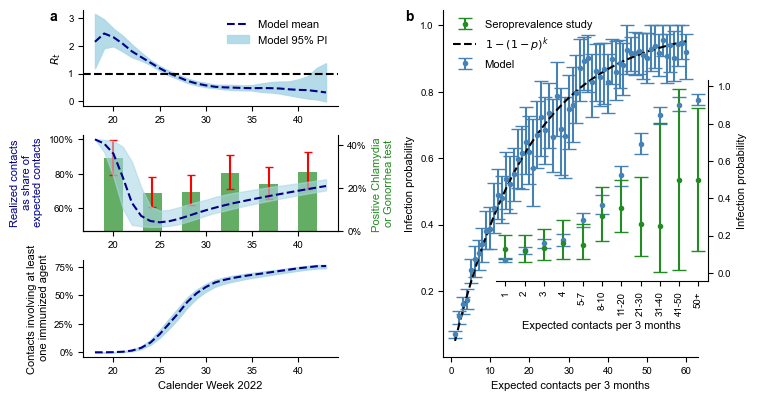

In [101]:
# Figure 3
fig = plt.figure(figsize=(x_size, y_size/2.7))

# left panel
# time lines
#t = np.linspace(0,25,26)
t = np.arange(18,44)

# R0
ax_r0 = fig.add_subplot(3,2,1)

ax_r0.plot(t, np.mean(LL_range_mean_degree_I.iloc[:,5:31].multiply(LL_range_mean_degree_I["inf_prob"], axis="index")*mean_infectious), color = "darkblue", linestyle = "dashed", label = "Model mean")
ax_r0.fill_between(t,LL_range_mean_degree_I.iloc[:,5:31].multiply(LL_range_mean_degree_I["inf_prob"], axis="index").quantile(0.025)*mean_infectious, LL_range_mean_degree_I.iloc[:,5:31].multiply(LL_range_mean_degree_I["inf_prob"], axis="index").quantile(0.975)*mean_infectious, color = "lightblue", alpha = 0.9, label = "Model 95% PI")
ax_r0.axhline(1, color = "black", linestyle = "dashed")
ax_r0.set_ylabel(r"$R_t$", **labelfont)
ax_r0.legend(frameon=False,prop={'size': legendfont})

r0_mean = np.mean(LL_range_mean_degree_I.iloc[:,5:31].multiply(LL_range_mean_degree_I["inf_prob"], axis="index")*mean_infectious)
r0_lower = LL_range_mean_degree_I.iloc[:,5:31].multiply(LL_range_mean_degree_I["inf_prob"], axis="index").quantile(0.025)*mean_infectious
r0_upper = LL_range_mean_degree_I.iloc[:,5:31].multiply(LL_range_mean_degree_I["inf_prob"], axis="index").quantile(0.975)*mean_infectious

print("R0 start")
print(r0_mean[0])
print(r0_lower[0])
print(r0_upper[0])

print("Rt second week")
print(r0_mean[1])
print(r0_lower[1])
print(r0_upper[1])

# contact changes
ax_cc = fig.add_subplot(3,2,3)
ax2 = ax_cc.twinx()
ax_cc.yaxis.tick_right()
ax_cc.yaxis.set_label_position("right")

# add STD data first
std_pos = [47, 22, 24, 37, 29, 32]
std_tests = [139, 126, 131, 138, 134, 117]
#std_x = [1, 6, 10, 15, 19, 23]
#std_x = [19, 24, 28, 33, 37, 41]
std_x = 20 + np.linspace(0,21,6)

y_errormin, y_errormax, std_y = [], [], []
for i in range(len(std_pos)):
    result = binomtest(std_pos[i], std_tests[i], p=std_pos[i]/std_tests[i])
    y_errormin.append(std_pos[i]/std_tests[i]-result.proportion_ci(confidence_level=0.95).low)
    y_errormax.append(result.proportion_ci(confidence_level=0.95).high- std_pos[i]/std_tests[i])
    std_y.append(std_pos[i]/std_tests[i])
yerr = [y_errormin, y_errormax]
ax_cc.bar(std_x, std_y, color = "forestgreen", width = 2, alpha = 0.7, zorder = 0)
ax_cc.errorbar(std_x, std_y, yerr=yerr, fmt='.k', color="r",  capsize=3, capthick=1, ms = 0)
ax_cc.yaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=0))
ax_cc.set_ylabel("Positive Chlamydia \nor Gonorrhea test", **labelfont, color = "forestgreen")


ax2.yaxis.tick_left()
ax2.yaxis.set_label_position("left")
ax2.spines['top'].set_visible(False)

ax2.plot(t,np.mean(LL_range_lambda, axis = 0)[5:31]/LL_range_lambda.iloc[0][5]*100, color = "darkblue", linestyle = "dashed", zorder = 15)
ax2.fill_between(t,LL_range_lambda.quantile(0.025)[5:31]/LL_range_lambda.iloc[0][5]*100, LL_range_lambda.quantile(0.975)[5:31]/LL_range_lambda.iloc[0][5]*100, color = "lightblue", alpha = 0.6, zorder = 10)
ax2.set_ylabel("Realized contacts\n as share of\n expected contacts", **labelfont, color = "darkblue")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

contact_mean = np.mean(LL_range_lambda, axis = 0)[5:31]/LL_range_lambda.iloc[0][5]*100
contact_lower = LL_range_lambda.quantile(0.025)[5:31]/LL_range_lambda.iloc[0][5]*100
contact_upper = LL_range_lambda.quantile(0.975)[5:31]/LL_range_lambda.iloc[0][5]*100

print("Contact changes")
print(contact_mean[7])
print(contact_lower[7])
print(contact_upper[7])

weeks = ["CW"+str(i) for i in range(18,44)]
print(weeks[7])
print(contact_mean[-1])
print(contact_lower[-1])
print(contact_upper[-1])



# contacts with immunized agents
ax_ia = fig.add_subplot(3,2,5)
ax_ia.set_xlabel("Calender Week 2022", **labelfont)
#ax.set_xticks(np.linspace(0,25, 26), ["CW"+str(i) for i in range(18,44)], rotation=90, **labelfont)
#ax.set_xticks(np.linspace(0,25, 26), [i for i in range(18,44)], rotation=90, **labelfont)

ax_ia.plot(t, np.mean(LL_range_R_lambda.iloc[:,5:31].multiply(1/LL_range_lambda.iloc[:,5:31], axis = "index"))/2*100, color = "darkblue", linestyle = "dashed")
ax_ia.fill_between(t, LL_range_R_lambda.iloc[:,5:31].multiply(1/LL_range_lambda.iloc[:,5:31], axis = "index").quantile(0.025)/2*100, LL_range_R_lambda.iloc[:,5:31].multiply(1/LL_range_lambda.iloc[:,5:31], axis = "index").quantile(0.975)/2*100, color = "lightblue", alpha = 0.9)
ax_ia.set_ylabel("Contacts involving at least\n one immunized agent", **labelfont)
ax_ia.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

contacts_immune_mean = np.mean(LL_range_R_lambda.iloc[:,5:31].multiply(1/LL_range_lambda.iloc[:,5:31], axis = "index"))/2*100
contacts_immune_lower = LL_range_R_lambda.iloc[:,5:31].multiply(1/LL_range_lambda.iloc[:,5:31], axis = "index").quantile(0.025)/2*100
contacts_immune_upper = LL_range_R_lambda.iloc[:,5:31].multiply(1/LL_range_lambda.iloc[:,5:31], axis = "index").quantile(0.975)/2*100
                                            
print("Contacts immune")
print(contacts_immune_mean[-1])
print(contacts_immune_lower[-1])
print(contacts_immune_upper[-1])


# ax beauty treatment
axes = [ax_r0, ax_cc, ax_ia]
for ax in axes:
    ax.spines['top'].set_visible(False)
    if ax != "ax_cc":
        ax.spines['right'].set_visible(False)
    #for end in month_end:
    #    ax.axvline(end, linestyle = "dashed", color = "black", linewidth = 0.1)
        
# months 
month_end = [22, 26, 30, 35, 39]
# unused at the moment

# right panel
values_all, counts_all = np.unique(mu, return_counts=True)

# probability of infection versus degree
ax = fig.add_subplot(1,2,2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

data = LL_range_I_degrees.iloc[:,5:65].values/counts_all
y_errormin = [np.mean(data, axis = 0) - np.quantile(data, 0.025, axis = 0)]
y_errormax = [-np.mean(data, axis = 0) + np.quantile(data, 0.975, axis = 0)]
c = [y_errormin[0], y_errormax[0]]
ax.errorbar(np.linspace(1,60,60),np.mean(data, axis = 0), yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1, label = "Model")

# fit curve through midpoints 
def curve(x, p):
    return 1-p**x

xs, counts = np.unique(data, return_counts= True)
ys = counts/np.sum(counts)
param_bounds=([0],[1])
p, cv = scipy.optimize.curve_fit(curve, values_all, np.mean(data, axis = 0), 0.9, bounds=param_bounds)
print(1-p)

ax.plot(values_all, curve(values_all, p), color = "black", linestyle = "dashed", label = r"$1-(1-p)^k$")
#ax.plot(values_all, 1-0.93**values_all, color = "black", linestyle = "dashed")

ax.set_ylabel("Infection probability", **labelfont)
ax.set_xlabel("Expected contacts per 3 months", **labelfont)


# inset: infection rate for survey classes
left, bottom, width, height = [0.7, 0.3, 0.3, 0.5]
ax2 = fig.add_axes([left, bottom, width, height])

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set(facecolor = '#FF000000')

y_errormin, y_errormax = [], []
middle, x = [],[]
for key in dic_coded.keys():
    infs = np.zeros(len(LL_range_I_degrees.iloc[:,5]))
    counts = 0
    for i in dic_coded[key]:
        infs += LL_range_I_degrees.iloc[:,4+i].to_numpy()
        counts += counts_all[i-1]
    
    y_errormin.append(np.mean(infs/counts) - np.quantile(infs/counts, 0.025))
    y_errormax.append(np.quantile(infs/counts, 0.975)- np.mean(infs/counts))
    middle.append(np.mean(infs/counts))
    x.append(int(key))


yerr = [y_errormin, y_errormax]
ax2.errorbar(x, middle, yerr=yerr, fmt='.k', capsize=5, capthick=1, color = "steelblue")

# seroprevalence study
contacts_total, counts_total = np.unique(data_combined["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
values, counts = np.unique(data_combined[data_combined["final_status"]==1]["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
print(values)
print(counts_total)
y_errormin, y_errormax = [], []
for i in range(len(counts)):
    result = binomtest(counts[i], counts_total[i], p=counts[i]/counts_total[i])
    y_errormin.append(counts[i]/counts_total[i]-result.proportion_ci(confidence_level=0.95).low)
    y_errormax.append(result.proportion_ci(confidence_level=0.95).high- counts[i]/counts_total[i])
yerr = [y_errormin, y_errormax]
ax2.errorbar(values, counts/counts_total, yerr=yerr, fmt='.k', capsize=5, capthick=1, label = "Seroprevalence study", color = "forestgreen")

ax2.set_ylabel("Infection probability", **labelfont)

ax2.set_xticks(x)
ax2.set_xticklabels(["1", "2","3","4","5-7","8-10","11-20","21-30","31-40","41-50","50+"], rotation=90)
ax2.set_xlabel("Expected contacts per 3 months", **labelfont)


# get labels from all axis
handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles2+handles, labels2+labels, frameon=False,prop={'size': legendfont}, loc="upper left")

plt.tight_layout()
# cosmetics
ax.text(-1.55,1,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-0.15,1,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

plt.savefig(path_to_plots+"/figure3.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/figure3.svg", bbox_inches='tight')

In [103]:
# Caution: could take several minutes

# get immune status of population share with 8 or more contacts
repo = path_to_results+"model/run3"

vaccinated = np.zeros((2, len(LL_range_D)))
infected = np.zeros((2,len(LL_range_D)))

# add zero contact vaccinations
vaccinated[0,:] += vaccinations_outside_network

s = 0
for i in LL_range_D.index:
    print(s)
    try:
        agent_info = pd.read_csv(repo+"/has_result_agent_info_"+str(i))
    except:
        print(i)

    for k in range(len(agent_info)):
        if agent_info.iloc[k]["mu"] >= 8:
            # check if infected
            if agent_info.iloc[k]["infection_source"] != 0:
                infected[1,s] += 1
            # check if vaccinated
            elif agent_info.iloc[k]["vaccination_status"]== 1:
                vaccinated[1,s] += 1
        
        else:
            # check if infected
            if agent_info.iloc[k]["infection_source"] != 0:
                infected[0,s] += 1
            # check if vaccinated
            elif agent_info.iloc[k]["vaccination_status"]== 1:
                vaccinated[0,s] += 1


    s += 1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142


In [104]:
# longest path
# number of secondary cases...
# do something with infection info 
repo = path_to_results+"model/run3"
number_secondary_cases = np.zeros(100)
count = 0
#for i in LL_range_D.index:
print(LL_range_D.index)
for i in LL_range_D.index:
    try:
        agent_info = pd.read_csv(repo+"/has_result_agent_info_"+str(i))
        total_infs = len(agent_info[agent_info["infection_source"] != 0]["infection_source"].to_numpy().astype(int))
        sources = agent_info[agent_info["infection_source"] > 0]["infection_source"].to_numpy().astype(int)

        values, counts = np.unique(sources, return_counts=True)
        values, counts = np.unique(counts, return_counts = True)
        number_secondary_cases[0] += total_infs - np.sum(counts)
        for k in range(len(values)):
            number_secondary_cases[values[k]] += counts[k]
        
        count +=1
    except:
        print(i)

print(count)

Int64Index([  1921,   2050,  10094,  14430,  18965,  23094,  23991,  28000,
             29605,  30673,
            ...
            464355, 473973, 474285, 475150, 478465, 482164, 487827, 492902,
            493817, 495430],
           dtype='int64', length=143)
143


In [105]:
# path length distribution
repo = path_to_results+"model/run3"
#number_secondary_cases = np.zeros(100)
count = 0
#for i in LL_range_D.index:

size_of_subtree = []
top1 = []
top2 = []
top3 = []
top4 = []
top5 = []

for k in LL_range_D.index:
    try:
        agent_info = pd.read_csv(repo+"/has_result_agent_info_"+str(k))
        print(k)
    except:
        print("File does not exist: "+k)
    
    total_infs = len(agent_info[agent_info["infection_source"] != 0]["infection_source"].to_numpy().astype(int))
    network = agent_info[agent_info["infection_source"] != 0][["infection_source","exposure_time"]]

    start_nodes = network[network["infection_source"] == -1].index.values

    G = defaultdict(list)

    for i in range(len(network)):
        if network.index[i] in start_nodes:
            continue 
        G[int(network.iloc[i]["infection_source"])].append(network.index[i])

#print(G.items())

    #Forest = defaultdict(list)

    forest = []

    for i in start_nodes:
        follower = G[i]
        t = 0
        while t != len(follower):
            follower += G[follower[t]]
            t+=1

        #print("Number follower")
        #print(len(follower))
        size_of_subtree.append(len(follower))
        forest.append(len(follower))
        #tree = DFS(G,i) 
        #if len(tree) >0 :
        #    print("Longest path")
        #    print(max(len(p) for p in tree))
            #print([len(p) for p in tree])
        #Forest[i].append(DFS(G,i))

    # find largest tree
    forest.sort(reverse=True)
    print(forest)
    top1.append(forest[0]/sum(forest))
    top2.append(forest[1]/sum(forest))
    top3.append(forest[2]/sum(forest))
    top4.append(forest[3]/sum(forest))
    top5.append(forest[4]/sum(forest))




1921
[2464, 1068, 879, 868, 475, 287, 264, 183, 174, 154, 2, 0, 0, 0, 0]
2050
[2519, 2090, 1010, 653, 394, 344, 280, 9, 0, 0]
10094
[1970, 959, 930, 834, 776, 649, 532, 375, 226, 215, 82, 80, 6, 2, 1, 1, 0, 0, 0]
14430
[1958, 1911, 1441, 1439, 343, 318, 67, 20, 2, 1, 1, 0, 0, 0, 0, 0]
18965
[2079, 1682, 1640, 943, 592, 185, 91, 26, 7, 3, 0]
23094
[2251, 1584, 1213, 989, 572, 367, 249, 31, 17, 1, 0]
23991
[2878, 1303, 935, 660, 592, 585, 353, 13, 3, 1, 0, 0, 0, 0, 0]
28000
[6529, 365, 218, 96, 35, 4, 1, 0, 0, 0, 0, 0, 0, 0]
29605
[1405, 1292, 1244, 989, 953, 703, 552, 166, 24, 2, 1, 1, 0]
30673
[4651, 1004, 570, 424, 277, 214, 65, 8, 6, 1, 0, 0, 0]
31030
[2063, 1503, 854, 500, 398, 369, 367, 236, 188, 2, 2, 1, 0, 0, 0, 0]
31354
[1836, 1727, 1653, 1582, 511, 342, 50, 24, 0, 0, 0]
31450
[1492, 1350, 1185, 753, 735, 700, 700, 366, 188, 13, 8, 2, 0, 0]
31454
[1783, 1289, 1069, 829, 737, 643, 470, 188, 184, 21, 9, 2, 2, 0]
33065
[2411, 2304, 950, 380, 272, 252, 199, 196, 171, 163, 135, 66, 3

0.12384783280833389
Means:
[32.3104883692399, 58.354803091645195, 9.334708539114905]
100.0
95% PI
28.924928600571196 35.1438188494492
54.36658506731946 62.373521011831905
8.347613219094248 10.760913912688697
Means:
[24.37787749943663, 8.24940492965157, 67.3727175709118]
100.0
95% PI
24.030224620127726 24.811807237759673
6.880092490640828 9.261910005138368
66.64868237539456 68.3730639359906
0.6127122624020565
0.18348826199136406
0.2037994756065795
0.012970085998239348
[37.465720300394516, 58.55553376624952, 73.12129890434768, 83.059021772711, 89.5725374353052]
[20.391060948577042, 37.384732570137885, 51.96533261693942, 62.93054804787377, 73.13881325734792]
[67.96694220520095, 86.20250937624591, 95.6089298701664, 98.71724777892867, 99.81791999981202]


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2303684384.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2303684384.py:51: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2303684384.py:96: RuntimeWarning: divide by zero encountered in log10
  ax2.scatter(np.log10(values),(counts)/np.sum(counts), color = "coral")
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2303684384.py:126: UserWarning: color is redundantly defined by the 'color' keyword a

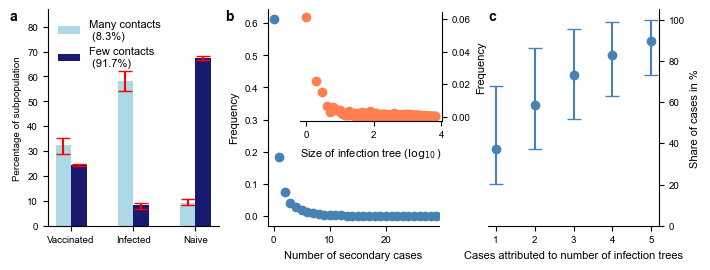

In [108]:
# Figure 4 version 2 
fig = plt.figure(figsize=(x_size, y_size/4))

# left panel
# infection, vaccination distribution
ax = fig.add_subplot(1,3,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
a = [0, 0.2, 0.4]
width = 0.05

# count contacts
values_all, counts_all = np.unique(mu, return_counts=True)
total = np.zeros((2,len(LL_range_I_degrees)))
# add zero contact group
total[0,:] += N - len(sampled_pop_active)

for i in range(len(values_all)):
    if values_all[i] <8:
        total[0,:] += counts_all[i]
    else:
        total[1,:] += counts_all[i]

print(np.mean(np.sum(infected, axis = 0)/np.sum(total, axis = 0)))
# high contacts
naive = total[1,:] - vaccinated[1,:] - infected[1,:]

b = [np.mean(vaccinated[1,:]*100/total[1,:]), np.mean(infected[1,:]*100/total[1,:]), np.mean(naive*100/total[1,:])]

y_errormin = [np.mean(vaccinated[1,:]*100/total[1,:]) - np.quantile(vaccinated[1,:]*100/total[1,:], 0.025),np.mean(infected[1,:]*100/total[1,:]) - np.quantile(infected[1,:]*100/total[1,:], 0.025), np.mean(naive*100/total[1,:]) - np.quantile(naive*100/total[1,:], 0.025)]
y_errormax = [-np.mean(vaccinated[1,:]*100/total[1,:]) + np.quantile(vaccinated[1,:]*100/total[1,:], 0.975),-np.mean(infected[1,:]*100/total[1,:]) + np.quantile(infected[1,:]*100/total[1,:], 0.975), -np.mean(naive*100/total[1,:]) + np.quantile(naive*100/total[1,:], 0.975)]
c = [y_errormin, y_errormax]
ax.bar(a, b, width = width, color = "lightblue", label = "Many contacts\n ("+str(round(total[1,0]/N*100,1))+"%)")
ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)
print("Means:")
print(b)
print(np.sum(b))
print("95% PI")
print(b[0]-y_errormin[0], b[0]+y_errormax[0])
print(b[1]-y_errormin[1], b[1]+y_errormax[1])
print(b[2]-y_errormin[2], b[2]+y_errormax[2])

# low contacts
naive = total[0,:] - vaccinated[0,:] - infected[0,:]
b = [np.mean(vaccinated[0,:]*100/total[0,:]), np.mean(infected[0,:]*100/total[0,:]), np.mean(naive*100/total[0,:])]
y_errormin = [np.mean(vaccinated[0,:]*100/total[0,:]) - np.quantile(vaccinated[0,:]*100/total[0,:], 0.025),np.mean(infected[0,:]*100/total[0,:]) - np.quantile(infected[0,:]*100/total[0,:], 0.025), np.mean(naive*100/total[0,:]) - np.quantile(naive*100/total[0,:], 0.025)]
y_errormax = [-np.mean(vaccinated[0,:]*100/total[0,:]) + np.quantile(vaccinated[0,:]*100/total[0,:], 0.975),-np.mean(infected[0,:]*100/total[0,:]) + np.quantile(infected[0,:]*100/total[0,:], 0.975), -np.mean(naive*100/total[0,:]) + np.quantile(naive*100/total[0,:], 0.975)]
c = [y_errormin, y_errormax]
a = [0.05, 0.25, 0.45]
ax.bar(a, b, width = width, color = "midnightblue", label = "Few contacts\n ("+str(round(total[0,0]/N*100,1))+"%)")
ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)
ax.legend(frameon=False,prop={'size': legendfont}, loc = "upper left")

ax.set_ylabel("Percentage of subpopulation")

ax.set_xticks([0.025, 0.225, 0.425])
ax.set_xticklabels(["Vaccinated", "Infected", "Naive"])

ax.set_ylim(0,87)

print("Means:")
print(b)
print(np.sum(b))
print("95% PI")
print(b[0]-y_errormin[0], b[0]+y_errormax[0])
print(b[1]-y_errormin[1], b[1]+y_errormax[1])
print(b[2]-y_errormin[2], b[2]+y_errormax[2])


# middle panel
ax = fig.add_subplot(1,3,2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.scatter(np.linspace(0,99,100), number_secondary_cases/np.sum(number_secondary_cases), color = "steelblue")
ax.set_xlim(-1,29.4)
ax.set_xlabel("Number of secondary cases", **labelfont)
ax.set_ylabel("Frequency", **labelfont)

print((number_secondary_cases/np.sum(number_secondary_cases))[0])
print((number_secondary_cases/np.sum(number_secondary_cases))[1])
print(1 - (number_secondary_cases/np.sum(number_secondary_cases))[0] - (number_secondary_cases/np.sum(number_secondary_cases))[1])
print(np.sum((number_secondary_cases/np.sum(number_secondary_cases))[9:]))

# inset
left, bottom, width, height = [0.42, 0.55, 0.2, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set(facecolor = '#FF000000')
values, counts = np.unique(size_of_subtree, return_counts=True)

ax2.scatter(np.log10(values),(counts)/np.sum(counts), color = "coral")
ax2.set_xlabel(r"Size of infection tree ($\log_{10}$)", **labelfont)
ax2.set_ylabel("Frequency", **labelfont)


# right panel 
ax = fig.add_subplot(1,3,3)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

top1a = np.asarray(top1)*100
top2a = np.asarray(top2)*100
top3a = np.asarray(top3)*100
top4a = np.asarray(top4)*100
top5a = np.asarray(top5)*100

data = [top1a, top1a+top2a, top1a+top2a+top3a, top1a+top2a+top3a+top4a, top1a+top2a+top3a+top4a+top5a]

y_errormin = [np.mean(x) - np.quantile(x,0.025) for x in data]
y_errormax = [-np.mean(x) + np.quantile(x,0.975) for x in data]
c = [y_errormin, y_errormax]

print([np.mean(x) for x in data])
print([np.quantile(x,0.025) for x in data])
print([np.quantile(x,0.975) for x in data])


ax.scatter([1,2,3,4,5], [np.mean(x) for x in data],color="steelblue",)
ax.errorbar([1,2,3,4,5], [np.mean(x) for x in data], yerr=c, fmt='.k', color="steelblue",  capsize=5, capthick=1)

ax.set_ylim(0,105)

ax.set_xticks([1,2,3,4,5])
#ax.set_xticklabels(["One tree","Two trees","Three trees","Four trees","Five trees"])#, rotation=45)
ax.set_xlabel("Cases attributed to number of infection trees", **labelfont)
ax.set_ylabel("Share of cases in %", **labelfont)




plt.tight_layout()

# cosmetics
ax.text(-2.8,1,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-1.54,1,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(0,1,
           'c',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

plt.savefig(path_to_plots+"/figure4.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/figure4.svg", bbox_inches='tight')


# Alternative Scenarios

## No vaccinations

In [ ]:
np.save(path_to_parameters+"alternatives/no_vaccinations/run1/vaccination_timeline.npy", np.zeros(len(vaccination_timeline_effect), dtype = int))

In [164]:
repo = path_to_results+"alternatives/no_vaccinations/run1"
#combine_results(repo)
multiple = 8
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)

511


## Run 2 (no vaccinations)

In [ ]:
####################################################################################################################################
################################### DONT RUN!!!!!!!!!!!!!!!!!!! ####################################################################
####################################################################################################################################

df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4], p = [0.01, 0.01,0.3, 0.35, 0.3, 0.01,0.01,0.01])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/10)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df.to_csv(path_to_parameters+"alternatives/no_vaccinations/run2/sampled_parameters.csv", index=False)


In [165]:
repo = path_to_results+"alternatives/no_vaccinations/run2"
#combine_results(repo, 1000)
multiple = 5
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)

4247


# Run 3 (without vaccinations)

In [ ]:
####################################################################################################################################
################################### DONT RUN!!!!!!!!!!!!!!!!!!! ####################################################################
####################################################################################################################################

df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

k = 0
for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4], p = [0.01, 0.01,0.3, 0.35, 0.3, 0.01,0.01,0.01])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/10)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df = pd.concat([df, df, df, df, df])
print(len(df))
df.to_csv(path_to_parameters+"alternatives/no_vaccinations/run3/sampled_parameters.csv", index=False)


In [197]:
repo = path_to_results+"alternatives/no_vaccinations/run3"
combine_results(repo, 5000)
partition_large_files(repo)

In [67]:
multiple = 3
repo = path_to_results+"alternatives/no_vaccinations/run3"
#LL_range_D, LL_range_I, LL_range_lambda, LL_range_R, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll(repo, multiple, LL_berlin)
LL_range_D, LL_range_I, LL_range_lambda, LL_range_R, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll_large(repo, multiple, LL_berlin)

100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
815


/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=

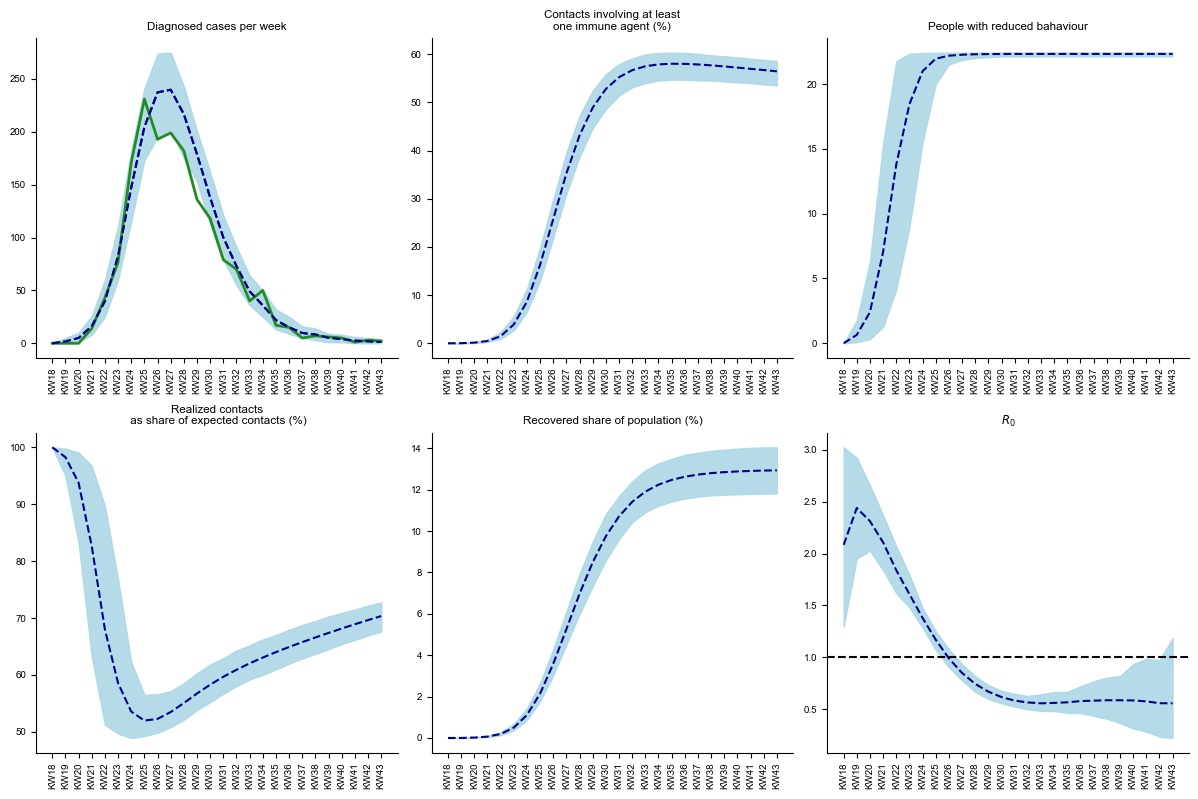

In [1056]:
fig = plot_timelines(LL_range_D, LL_range_R, LL_range_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_R_lambda, N, mean_infectious, berlin)

plt.tight_layout()
#plt.savefig("/Users/nilsgubela/Desktop/Projects/Ideas/MPox/simulation/documentation/figs/result_timelines.pdf", bbox_inches='tight')
plt.show()

inf_prob
0.6839432694001903
0.6484400598401234
0.7055415872658772
diag_prob
0.24284113917322495
0.2259928404170812
0.2621050087929129
i0
14.374233128834355
10.0
19.0
Recovered
12.936342127057928
11.821059366265953
14.050240765060442
Immunized
12.936342127057928
11.821059366265953
14.050240765060442


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3056394957.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3056394957.py:64: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3056394957.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/

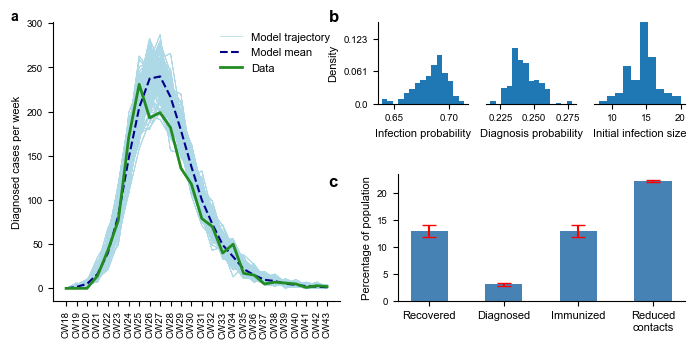

In [68]:
# Figure 1 version 2
fig = plt.figure(figsize=(x_size*1.15, y_size/3))

# left panel
# model fit
t = np.linspace(0,25,26)
ax = fig.add_subplot(1,2,1)
#ax.fill_between(t,LL_range_D.quantile(0.025)[5:31], LL_range_D.quantile(0.975)[5:31], color = "lightblue", alpha = 0.9, label = "Model 95% PI")
for i in range(len(LL_range_D)-1):
    ax.plot(LL_range_D.iloc[i, 5:31], color = "lightblue", linewidth = 0.5)
ax.plot(LL_range_D.iloc[i+1, 5:31], color = "lightblue", linewidth = 0.5, label = "Model trajectory")
ax.plot(np.mean(LL_range_D, axis = 0)[5:31], color = "darkblue", linestyle = "dashed", label = "Model mean")

ax.set_xticks(np.linspace(0,25, 26), ["CW"+str(i) for i in range(18,44)], rotation=90)
ax.plot(berlin[:26], color = "forestgreen", linewidth = 2, label = "Data")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Diagnosed cases per week", **labelfont)
ax.legend(frameon=False,prop={'size': legendfont})

# upper right panel
# posterior distributions

columns = ["inf_prob", "diag_prob", "i0"]
bins = [15,15,10]
titles = ["Infection probability", "Diagnosis probability", "Initial infection size"]
i=0
for col in columns:
    #ax = fig.add_subplot(3,12,8+2*i)
    ax = fig.add_subplot(3,6,4+i)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    print(col)
    print(np.mean(LL_range_D[col]))
    print(LL_range_D[col].quantile(0.025))
    print(LL_range_D[col].quantile(0.975))
    ax.hist(LL_range_D[col], density = False, bins = bins[i])
    locs, _ = plt.yticks() 
    ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
    if i > 0:
        ax.get_yaxis().set_visible(False) 
        ax.spines['left'].set_visible(False)
    ax.set_ylim(0,250)   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(titles[i], **labelfont)
    ax.set_ylabel("Density", **labelfont)
    i+=1
#fig.tight_layout()


# lower right
# bar plots
ax = fig.add_subplot(2,2,4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
width = 0.5

# recovered
y_errormin = [np.mean(LL_range_R.iloc[:,30])/N*100 - np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,30])/N*100 + np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(0,np.mean(LL_range_R.iloc[:,30])/N*100, width = width, color = "steelblue")
plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Recovered")
print(np.mean(LL_range_R.iloc[:,30])/N*100)
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025))
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975))


# diagnosed
y_errormin = [np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 - np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 + np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
#ax.bar(2,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/LL_range_R.iloc[:,30]*100), width = width)
ax.bar(1,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)

# immunized
y_errormin = [np.mean(LL_range_R.iloc[:,30])/N*100 - np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,30])/N*100 + np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(2,np.mean(LL_range_R.iloc[:,30])/N*100, width = width, color = "steelblue")
plt.errorbar(2, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Immunized")
print(np.mean(LL_range_R.iloc[:,30])/N*100)
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025))
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975))


# contact reduced
y_errormin = [np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) - np.quantile(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) + np.quantile(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(3,np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(3, np.mean(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)

ax.set_ylabel("Percentage of population", **labelfont)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(["Recovered", "Diagnosed", "Immunized", "Reduced\ncontacts"], **labelfont)


# cosmetics
ax.text(-1.35,2.3,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-0.24,2.3,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=12,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(-0.24,1,
           'c',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=12,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


plt.savefig(path_to_plots+"/a_m_novaccines.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/a_m_novaccines.svg", bbox_inches='tight')

[ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
0.12955389309324794
0.9174664107485605
0.08253358925143954
Means:
[8.685509754569704, 60.42056203427673]
95% PI
7.659839976510313 9.623430962343097
57.32354141166871 63.831089351285186


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2089438650.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax2.errorbar(x, middle, yerr=yerr, fmt='.k', capsize=5, capthick=1, color = "steelblue")
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2089438650.py:39: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax2.errorbar(values, counts/counts_total, yerr=yerr, fmt='.k', capsize=5, capthick=1, label = "Seroprevalence study", color = "forestgreen")
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2089438650.py:87: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(a, b, yerr=c, fmt='.k', color="r

Text(1.2, 1, 'b')

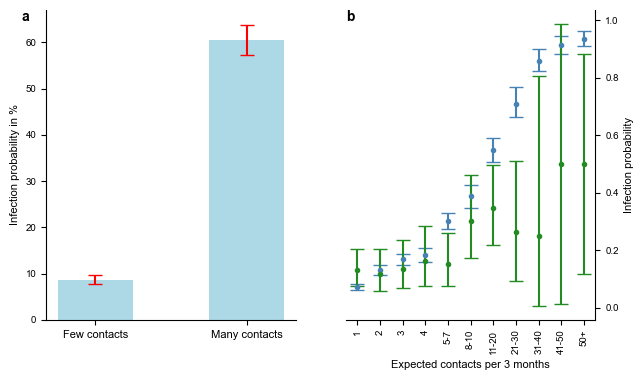

In [69]:
fig = plt.figure(figsize=(x_size, y_size/2.7))

# probability of infection versus degree
ax2 = fig.add_subplot(1,2,2)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set(facecolor = '#FF000000')

y_errormin, y_errormax = [], []
middle, x = [],[]
for key in dic_coded.keys():
    infs = np.zeros(len(LL_range_I_degrees.iloc[:,5]))
    counts = 0
    for i in dic_coded[key]:
        infs += LL_range_I_degrees.iloc[:,4+i].to_numpy()
        counts += counts_all[i-1]
    
    y_errormin.append(np.mean(infs/counts) - np.quantile(infs/counts, 0.025))
    y_errormax.append(np.quantile(infs/counts, 0.975)- np.mean(infs/counts))
    middle.append(np.mean(infs/counts))
    x.append(int(key))


yerr = [y_errormin, y_errormax]
ax2.errorbar(x, middle, yerr=yerr, fmt='.k', capsize=5, capthick=1, color = "steelblue")

# seroprevalence study
contacts_total, counts_total = np.unique(data_combined["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
values, counts = np.unique(data_combined[data_combined["final_status"]==1]["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
print(values)
y_errormin, y_errormax = [], []
for i in range(len(counts)):
    result = binomtest(counts[i], counts_total[i], p=counts[i]/counts_total[i])
    y_errormin.append(counts[i]/counts_total[i]-result.proportion_ci(confidence_level=0.95).low)
    y_errormax.append(result.proportion_ci(confidence_level=0.95).high- counts[i]/counts_total[i])
yerr = [y_errormin, y_errormax]
ax2.errorbar(values, counts/counts_total, yerr=yerr, fmt='.k', capsize=5, capthick=1, label = "Seroprevalence study", color = "forestgreen")

ax2.set_ylabel("Infection probability", **labelfont)

ax2.set_xticks(x)
ax2.set_xticklabels(["1", "2","3","4","5-7","8-10","11-20","21-30","31-40","41-50","50+"], rotation=90)
ax2.set_xlabel("Expected contacts per 3 months", **labelfont)

# get labels from all axis
handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles2+handles, labels2+labels, frameon=False,prop={'size': legendfont}, loc="upper left")

# left panel
ax = fig.add_subplot(1,2,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

values_all, counts_all = np.unique(mu, return_counts=True)

total = np.zeros((2,len(LL_range_I_degrees)))
infected = np.zeros((2,len(LL_range_I_degrees)))
# add zero contact group
total[0,:] += N - len(sampled_pop_active)

for i in range(len(values_all)):
    if values_all[i] <8:
        infected[0,:] += LL_range_I_degrees.iloc[:,5+i].to_numpy()
        total[0,:] += counts_all[i]
    else:
        infected[1,:] += LL_range_I_degrees.iloc[:,5+i].to_numpy()
        total[1,:] += counts_all[i]
    
print(np.mean(np.sum(infected, axis = 0)/np.sum(total, axis = 0)))

print(total[0,0]/N)
print(total[1,0]/N)

a = [0, 0.2]
# to get percentages
infected *= 100
b = [np.mean(infected[0,:]/total[0,:]), np.mean(infected[1,:]/total[1,:])]

y_errormin = [np.mean(infected[0,:]/total[0,:]) - np.quantile(infected[0,:]/total[0,:], 0.025),np.mean(infected[1,:]/total[1,:]) - np.quantile(infected[1,:]/total[1,:], 0.025)]
y_errormax = [-np.mean(infected[0,:]/total[0,:]) + np.quantile(infected[0,:]/total[0,:], 0.975), -np.mean(infected[1,:]/total[1,:])+np.quantile(infected[1,:]/total[1,:], 0.975)]
c = [y_errormin, y_errormax]

ax.bar(a, b, width = 0.1, color = "lightblue")
ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)
print("Means:")
print(b)
print("95% PI")
print(b[0]-y_errormin[0], b[0]+y_errormax[0])
print(b[1]-y_errormin[1], b[1]+y_errormax[1])

ax.set_xticks(a)
ax.set_xticklabels(["Few contacts", "Many contacts"], **labelfont)
ax.set_ylabel("Infection probability in %", **labelfont)


# cosmetics
#fig.tight_layout()

ax.text(-0.1,1,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(1.2,1,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


#plt.savefig(path_to_plots+"/figure3.pdf", bbox_inches='tight')
#plt.savefig(path_to_plots+"/figure3.svg", bbox_inches='tight')

## Low behaviour change

In [238]:
repo = path_to_results+"alternatives/low_behaviour_change/run1"
#combine_results(repo)
multiple = 8
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)

208


## Run 2 (low b.c.)

In [ ]:
####################################################################################################################################
################################### DONT RUN!!!!!!!!!!!!!!!!!!! ####################################################################
####################################################################################################################################

df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4], p = [0.01, 0.01,0.3, 0.35, 0.3, 0.01,0.01,0.01])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/10)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df.to_csv(path_to_parameters+"alternatives/low_behaviour_change/run2/sampled_parameters.csv", index=False)


In [239]:
repo = path_to_results+"alternatives/low_behaviour_change/run2"
#combine_results(repo, 1000)
multiple = 5
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)

272


## Run 3 (low b.c.)

In [ ]:
####################################################################################################################################
################################### DONT RUN!!!!!!!!!!!!!!!!!!! ####################################################################
####################################################################################################################################

df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

k = 0
for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4], p = [0.01, 0.01,0.3, 0.35, 0.3, 0.01,0.01,0.01])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/10)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df = pd.concat([df, df, df, df, df])
print(len(df))
df.to_csv(path_to_parameters+"alternatives/low_behaviour_change/run3/sampled_parameters.csv", index=False)


In [70]:
repo = path_to_results+"alternatives/low_behaviour_change/run3"
#combine_results(repo, 5000)
multiple = 5
LL_range_D, LL_range_I, LL_range_lambda, LL_range_R, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll_large(repo, multiple, LL_berlin)
LL_low_bc = LL_range_D["LL"].values

100000
100000
0
0
0
0
0
0
0
0
1122


/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=

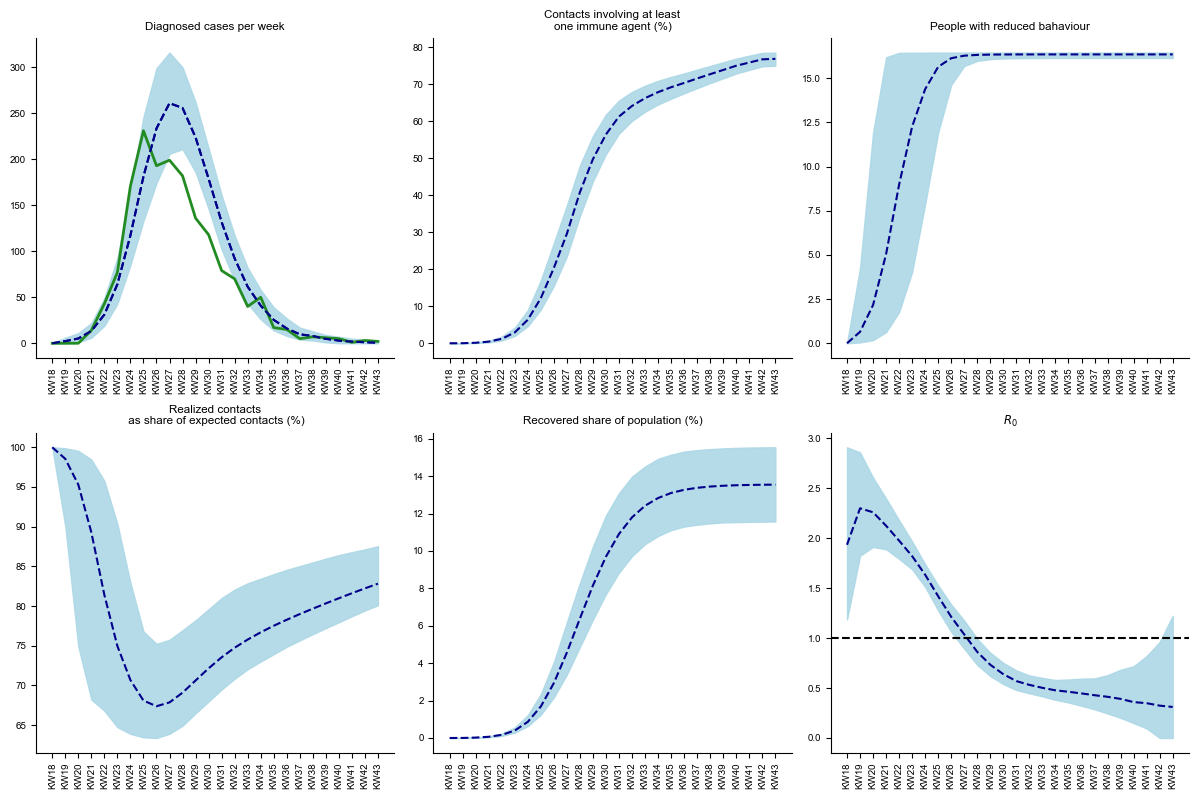

In [1035]:
fig = plot_timelines(LL_range_D, LL_range_R, LL_range_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_R_lambda, N, mean_infectious, berlin)

plt.tight_layout()
#plt.savefig("/Users/nilsgubela/Desktop/Projects/Ideas/MPox/simulation/documentation/figs/result_timelines.pdf", bbox_inches='tight')
plt.show()

inf_prob
0.654940333900492
0.6232201871966431
0.6888165345253613
diag_prob
0.2482922287913746
0.2266154529080325
0.29688174550123286
i0
16.402852049910873
11.0
20.0
Recovered
13.54577249230898
11.572128497828063
15.541973936761288
30.924999999999997
Immunized
37.85079120867644
36.697309492541336
39.02890022561201


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3149570542.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3149570542.py:64: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/3149570542.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/

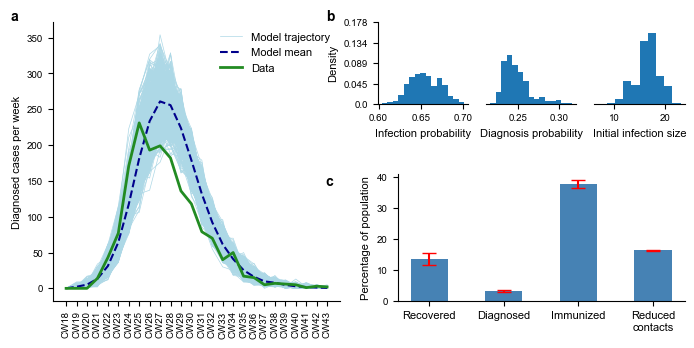

In [71]:
# Figure 1 version 2
fig = plt.figure(figsize=(x_size*1.15, y_size/3))

# left panel
# model fit
t = np.linspace(0,25,26)
ax = fig.add_subplot(1,2,1)
#ax.fill_between(t,LL_range_D.quantile(0.025)[5:31], LL_range_D.quantile(0.975)[5:31], color = "lightblue", alpha = 0.9, label = "Model 95% PI")
for i in range(len(LL_range_D)-1):
    ax.plot(LL_range_D.iloc[i, 5:31], color = "lightblue", linewidth = 0.5)
ax.plot(LL_range_D.iloc[i+1, 5:31], color = "lightblue", linewidth = 0.5, label = "Model trajectory")
ax.plot(np.mean(LL_range_D, axis = 0)[5:31], color = "darkblue", linestyle = "dashed", label = "Model mean")

ax.set_xticks(np.linspace(0,25, 26), ["CW"+str(i) for i in range(18,44)], rotation=90)
ax.plot(berlin[:26], color = "forestgreen", linewidth = 2, label = "Data")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Diagnosed cases per week", **labelfont)
ax.legend(frameon=False,prop={'size': legendfont})

# upper right panel
# posterior distributions

columns = ["inf_prob", "diag_prob", "i0"]
bins = [15,15,10]
titles = ["Infection probability", "Diagnosis probability", "Initial infection size"]
i=0
for col in columns:
    #ax = fig.add_subplot(3,12,8+2*i)
    ax = fig.add_subplot(3,6,4+i)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    print(col)
    print(np.mean(LL_range_D[col]))
    print(LL_range_D[col].quantile(0.025))
    print(LL_range_D[col].quantile(0.975))
    ax.hist(LL_range_D[col], density = False, bins = bins[i])
    locs, _ = plt.yticks() 
    ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
    if i > 0:
        ax.get_yaxis().set_visible(False) 
        ax.spines['left'].set_visible(False)
    ax.set_ylim(0,400)   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(titles[i], **labelfont)
    ax.set_ylabel("Density", **labelfont)
    i+=1
#fig.tight_layout()


# lower right
# bar plots
ax = fig.add_subplot(2,2,4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
width = 0.5

# recovered
y_errormin = [np.mean(LL_range_R.iloc[:,30])/N*100 - np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,30])/N*100 + np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(0,np.mean(LL_range_R.iloc[:,30])/N*100, width = width, color = "steelblue")
plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Recovered")
print(np.mean(LL_range_R.iloc[:,30])/N*100)
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025))
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975))
print(12.37/0.4)

# diagnosed
y_errormin = [np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 - np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 + np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
#ax.bar(2,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/LL_range_R.iloc[:,30]*100), width = width)
ax.bar(1,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)

# immunized
y_errormin = [np.mean(LL_range_R.iloc[:,31] + vaccinations_outside_network)/N*100 - np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,31] + vaccinations_outside_network)/N*100 + np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(2,np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, width = width, color = "steelblue")
ax.errorbar(2, np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Immunized")
print(np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100)
print(np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.025))
print(np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.975))


# contact reduced
y_errormin = [np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) - np.quantile(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) + np.quantile(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(3,np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(3, np.mean(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)

ax.set_ylabel("Percentage of population", **labelfont)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(["Recovered", "Diagnosed", "Immunized", "Reduced\ncontacts"], **labelfont)


# cosmetics
ax.text(-1.35,2.3,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-0.25,2.3,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(-0.25,1,
           'c',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


plt.savefig(path_to_plots+"/a_m_low_bc.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/a_m_low_bc.svg", bbox_inches='tight')

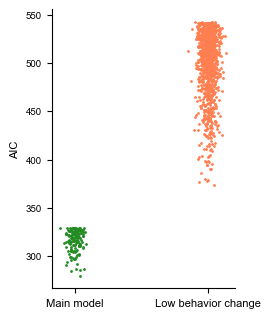

In [72]:
# AIC comparision between model and alternative
fig = plt.figure(figsize=(x_size/3, y_size/3))

ax = fig.add_subplot(1,1,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

AIC_model = 2*5 - 2*LL_model
AIC_low_bc = 2*5 - 2*LL_low_bc

ax.scatter(np.zeros(len(AIC_model))+ np.random.normal(0,0.04,len(AIC_model)), AIC_model, color = "forestgreen", s = 1)
ax.scatter(np.ones(len(AIC_low_bc))++ np.random.normal(0,0.04,len(AIC_low_bc)), AIC_low_bc, color = "coral", s = 1)

ax.set_ylabel("AIC", **labelfont)
ax.set_xticks([0,1])
ax.set_xticklabels(["Main model", "Low behavior change"], **labelfont)
plt.savefig(path_to_plots+"/AIC_low_bc.pdf", bbox_inches='tight')

## No behaviour change

In [245]:
repo = path_to_results+"alternatives/no_behaviour_change/run1"
#combine_results(repo)
multiple = 8
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)

70


## Run2 (no b.c.)

In [ ]:
####################################################################################################################################
################################### DONT RUN!!!!!!!!!!!!!!!!!!! ####################################################################
####################################################################################################################################

df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4], p = [0.01, 0.01,0.3, 0.35, 0.3, 0.01,0.01,0.01])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/10)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df.to_csv(path_to_parameters+"alternatives/no_behaviour_change/run2/sampled_parameters.csv", index=False)


In [246]:
repo = path_to_results+"alternatives/no_behaviour_change/run2"
#combine_results(repo, 1000)
multiple = 5
LL_range_D = apply_ll_D(repo, multiple, LL_berlin)

57


## Run 3 (no b.c.)

In [ ]:
####################################################################################################################################
################################### DONT RUN!!!!!!!!!!!!!!!!!!! ####################################################################
####################################################################################################################################

df= pd.DataFrame(columns=['inf_rate', 'diag_prob', 'i0', 'behaviour_change', 'behaviour_change_rate'])

np.random.seed(7)

k = 0
for i in range(100000):
    k = np.random.choice(len(LL_range_D))
    i0 = LL_range_D.iloc[k]["i0"] + np.random.choice([-3, -2, -1, 0, 1, 2, 3, 4], p = [0.01, 0.01,0.3, 0.35, 0.3, 0.01,0.01,0.01])
    inf_rate = LL_range_D.iloc[k]["inf_prob"] + np.random.normal(0, 0.005)
    if inf_rate > 0.99 or inf_rate < 0:
        inf_rate = LL_range_D.iloc[k]["inf_prob"]

    diag_prob = LL_range_D.iloc[k]["diag_prob"] + np.random.normal(0, 0.005)
    if diag_prob > 0.99 or diag_prob < 0:
        diag_prob = LL_range_D.iloc[k]["diag_prob"]
    
    behaviour_change = LL_range_D.iloc[k]["behaviour_change"] +  np.random.normal(0, 0.005)
    if behaviour_change < 0:
        behaviour_change = LL_range_D.iloc[k]["behaviour_change"]

    behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"] + np.random.normal(0, LL_range_D.iloc[k]["behaviour_change_rate"]/10)
    if behaviour_change_rate < 0:
        behaviour_change_rate = LL_range_D.iloc[k]["behaviour_change_rate"]

    df.loc[i] = [inf_rate, diag_prob, i0, behaviour_change, behaviour_change_rate]

df = pd.concat([df, df, df, df, df])
print(len(df))
df.to_csv(path_to_parameters+"alternatives/no_behaviour_change/run3/sampled_parameters.csv", index=False)


In [73]:
repo = path_to_results+"alternatives/no_behaviour_change/run3"
#combine_results(repo, 5000)
multiple = 5
LL_range_D, LL_range_I, LL_range_lambda, LL_range_R, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll_large(repo, multiple, LL_berlin)
LL_no_bc = LL_range_D["LL"].values

100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
1216


/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nilsgubela/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=

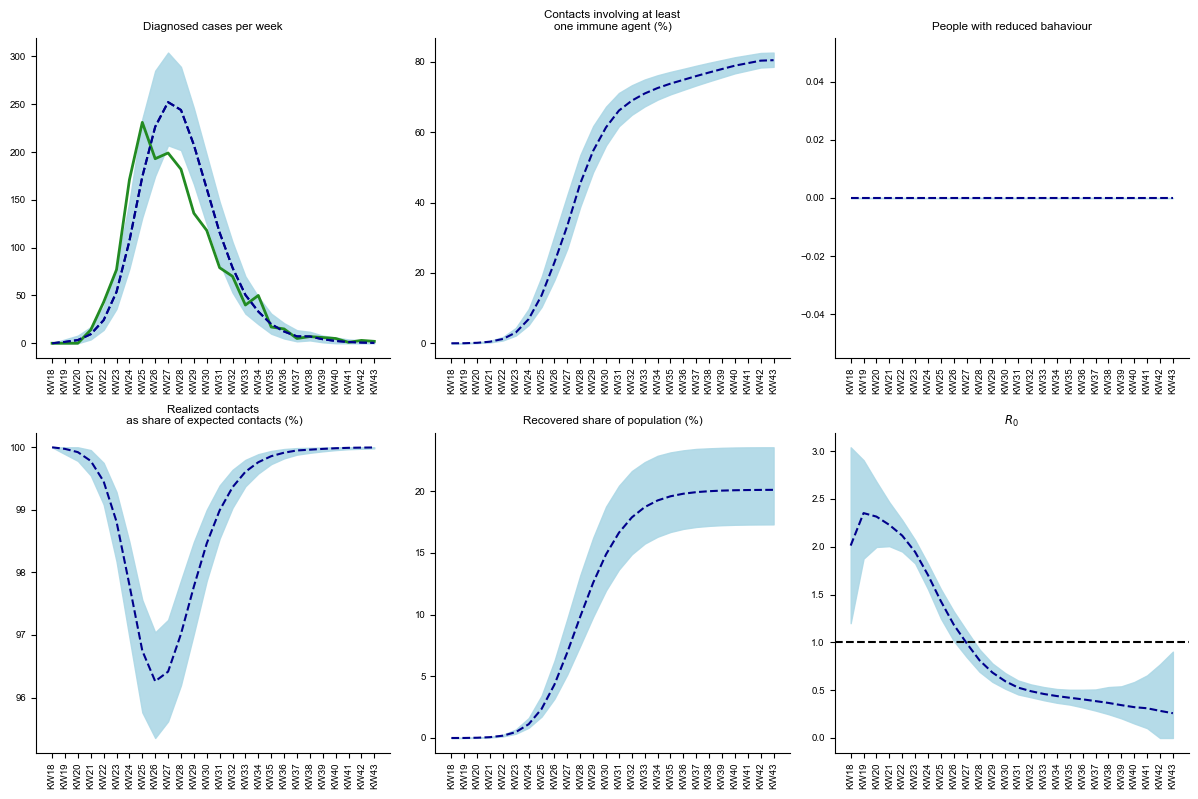

In [1271]:
fig = plot_timelines(LL_range_D, LL_range_R, LL_range_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_R_lambda, N, mean_infectious, berlin)

plt.tight_layout()
#plt.savefig("/Users/nilsgubela/Desktop/Projects/Ideas/MPox/simulation/documentation/figs/result_timelines.pdf", bbox_inches='tight')
plt.show()

inf_prob
0.662553518958413
0.6304762916416236
0.6972394328087765
diag_prob
0.15329324446008263
0.1234129674129718
0.18270426991207517
i0
15.756578947368421
10.0
19.0
Recovered
20.110503696988708
17.311512947435766
23.55814560393306
30.924999999999997
Immunized
41.0322297972682
39.427172778395125
43.02749435969963


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2775469026.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2775469026.py:64: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2775469026.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/

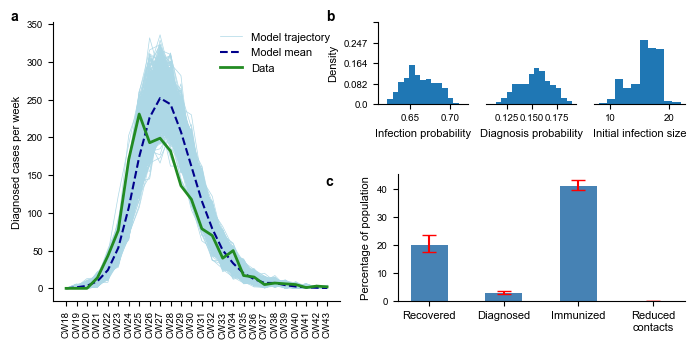

In [74]:
# Figure 1 version 2
fig = plt.figure(figsize=(x_size*1.15, y_size/3))

# left panel
# model fit
t = np.linspace(0,25,26)
ax = fig.add_subplot(1,2,1)
#ax.fill_between(t,LL_range_D.quantile(0.025)[5:31], LL_range_D.quantile(0.975)[5:31], color = "lightblue", alpha = 0.9, label = "Model 95% PI")
for i in range(len(LL_range_D)-1):
    ax.plot(LL_range_D.iloc[i, 5:31], color = "lightblue", linewidth = 0.5)
ax.plot(LL_range_D.iloc[i+1, 5:31], color = "lightblue", linewidth = 0.5, label = "Model trajectory")
ax.plot(np.mean(LL_range_D, axis = 0)[5:31], color = "darkblue", linestyle = "dashed", label = "Model mean")

ax.set_xticks(np.linspace(0,25, 26), ["CW"+str(i) for i in range(18,44)], rotation=90)
ax.plot(berlin[:26], color = "forestgreen", linewidth = 2, label = "Data")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Diagnosed cases per week", **labelfont)
ax.legend(frameon=False,prop={'size': legendfont})

# upper right panel
# posterior distributions

columns = ["inf_prob", "diag_prob", "i0"]
bins = [15,15,10]
titles = ["Infection probability", "Diagnosis probability", "Initial infection size"]
i=0
for col in columns:
    #ax = fig.add_subplot(3,12,8+2*i)
    ax = fig.add_subplot(3,6,4+i)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    print(col)
    print(np.mean(LL_range_D[col]))
    print(LL_range_D[col].quantile(0.025))
    print(LL_range_D[col].quantile(0.975))
    ax.hist(LL_range_D[col], density = False, bins = bins[i])
    locs, _ = plt.yticks() 
    ax.set_yticklabels(np.round(locs/len(LL_range_D[col]),3))
    if i > 0:
        ax.get_yaxis().set_visible(False) 
        ax.spines['left'].set_visible(False)
    ax.set_ylim(0,400)   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(titles[i], **labelfont)
    ax.set_ylabel("Density", **labelfont)
    i+=1
#fig.tight_layout()


# lower right
# bar plots
ax = fig.add_subplot(2,2,4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
width = 0.5

# recovered
y_errormin = [np.mean(LL_range_R.iloc[:,30])/N*100 - np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,30])/N*100 + np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(0,np.mean(LL_range_R.iloc[:,30])/N*100, width = width, color = "steelblue")
plt.errorbar(0, np.mean(LL_range_R.iloc[:,30])/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Recovered")
print(np.mean(LL_range_R.iloc[:,30])/N*100)
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.025))
print(np.quantile(LL_range_R.iloc[:,30]/N*100, 0.975))
print(12.37/0.4)

# diagnosed
y_errormin = [np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 - np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1))/N*100 + np.quantile(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
#ax.bar(2,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/LL_range_R.iloc[:,30]*100), width = width)
ax.bar(1,np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(1, np.mean(np.sum(LL_range_D.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)

# immunized
y_errormin = [np.mean(LL_range_R.iloc[:,31] + vaccinations_outside_network)/N*100 - np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.025)]
y_errormax = [-np.mean(LL_range_R.iloc[:,31] + vaccinations_outside_network)/N*100 + np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(2,np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, width = width, color = "steelblue")
ax.errorbar(2, np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)
print("Immunized")
print(np.mean(LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100)
print(np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.025))
print(np.quantile((LL_range_R.iloc[:,31]+vaccinations_outside_network)/N*100, 0.975))


# contact reduced
y_errormin = [np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) - np.quantile(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100, 0.025)]
y_errormax = [-np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100) + np.quantile(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(3,np.mean(np.sum(LL_range_M.iloc[:, 5:31], axis = 1)/N*100), width = width, color = "steelblue")
ax.errorbar(3, np.mean(np.sum(LL_range_M.iloc[:,5:31], axis = 1)/N*100), yerr=c, fmt='.k', color="r",  capsize=5, capthick=1,  ms = 0)

ax.set_ylabel("Percentage of population", **labelfont)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(["Recovered", "Diagnosed", "Immunized", "Reduced\ncontacts"], **labelfont)


# cosmetics
ax.text(-1.35,2.3,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


ax.text(-0.25,2.3,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(-0.25,1,
           'c',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


plt.savefig(path_to_plots+"/a_m_no_bc.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/a_m_no_bc.svg", bbox_inches='tight')

/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2300205461.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax2.errorbar(x, middle, yerr=yerr, fmt='.k', capsize=5, capthick=1, color = "steelblue")
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2300205461.py:39: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax2.errorbar(values, counts/counts_total, yerr=yerr, fmt='.k', capsize=5, capthick=1, label = "Seroprevalence study", color = "forestgreen")
/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/2300205461.py:83: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(a, b, yerr=c, fmt='.k', color="r

[ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]
Means:
[14.666943505951622, 80.69296366681698]
95% PI
12.112787198120825 17.861337444028482
74.91585067319461 86.80130558955528


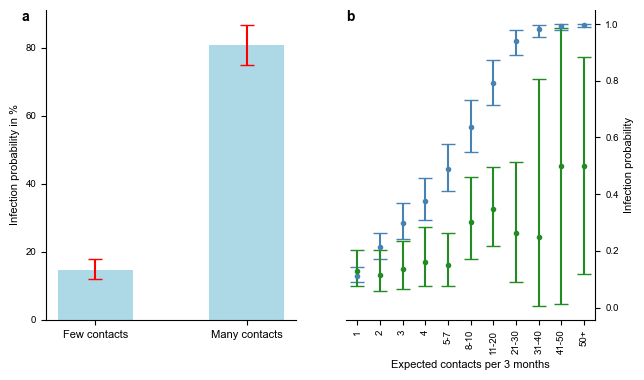

In [75]:
fig = plt.figure(figsize=(x_size, y_size/2.7))

# probability of infection versus degree
ax2 = fig.add_subplot(1,2,2)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set(facecolor = '#FF000000')

y_errormin, y_errormax = [], []
middle, x = [],[]
for key in dic_coded.keys():
    infs = np.zeros(len(LL_range_I_degrees.iloc[:,5]))
    counts = 0
    for i in dic_coded[key]:
        infs += LL_range_I_degrees.iloc[:,4+i].to_numpy()
        counts += counts_all[i-1]
    
    y_errormin.append(np.mean(infs/counts) - np.quantile(infs/counts, 0.025))
    y_errormax.append(np.quantile(infs/counts, 0.975)- np.mean(infs/counts))
    middle.append(np.mean(infs/counts))
    x.append(int(key))


yerr = [y_errormin, y_errormax]
ax2.errorbar(x, middle, yerr=yerr, fmt='.k', capsize=5, capthick=1, color = "steelblue")

# seroprevalence study
contacts_total, counts_total = np.unique(data_combined["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
values, counts = np.unique(data_combined[data_combined["final_status"]==1]["SEX_PARTNERS_MALE_ANAL"], return_counts= True)
print(values)
y_errormin, y_errormax = [], []
for i in range(len(counts)):
    result = binomtest(counts[i], counts_total[i], p=counts[i]/counts_total[i])
    y_errormin.append(counts[i]/counts_total[i]-result.proportion_ci(confidence_level=0.95).low)
    y_errormax.append(result.proportion_ci(confidence_level=0.95).high- counts[i]/counts_total[i])
yerr = [y_errormin, y_errormax]
ax2.errorbar(values, counts/counts_total, yerr=yerr, fmt='.k', capsize=5, capthick=1, label = "Seroprevalence study", color = "forestgreen")

ax2.set_ylabel("Infection probability", **labelfont)

ax2.set_xticks(x)
ax2.set_xticklabels(["1", "2","3","4","5-7","8-10","11-20","21-30","31-40","41-50","50+"], rotation=90)
ax2.set_xlabel("Expected contacts per 3 months", **labelfont)

# get labels from all axis
handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles2+handles, labels2+labels, frameon=False,prop={'size': legendfont}, loc="upper left")

# left panel
ax = fig.add_subplot(1,2,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

values_all, counts_all = np.unique(mu, return_counts=True)

total = np.zeros((2,len(LL_range_I_degrees)))
infected = np.zeros((2,len(LL_range_I_degrees)))
# add zero contact group
total[0,:] += N - len(sampled_pop_active)

for i in range(len(values_all)):
    if values_all[i] <8:
        infected[0,:] += LL_range_I_degrees.iloc[:,5+i].to_numpy()
        total[0,:] += counts_all[i]
    else:
        infected[1,:] += LL_range_I_degrees.iloc[:,5+i].to_numpy()
        total[1,:] += counts_all[i]
    

a = [0, 0.2]
# to get percentages
infected *= 100
b = [np.mean(infected[0,:]/total[0,:]), np.mean(infected[1,:]/total[1,:])]

y_errormin = [np.mean(infected[0,:]/total[0,:]) - np.quantile(infected[0,:]/total[0,:], 0.025),np.mean(infected[1,:]/total[1,:]) - np.quantile(infected[1,:]/total[1,:], 0.025)]
y_errormax = [-np.mean(infected[0,:]/total[0,:]) + np.quantile(infected[0,:]/total[0,:], 0.975), -np.mean(infected[1,:]/total[1,:])+np.quantile(infected[1,:]/total[1,:], 0.975)]
c = [y_errormin, y_errormax]

ax.bar(a, b, width = 0.1, color = "lightblue")
ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)
print("Means:")
print(b)
print("95% PI")
print(b[0]-y_errormin[0], b[0]+y_errormax[0])
print(b[1]-y_errormin[1], b[1]+y_errormax[1])

ax.set_xticks(a)
ax.set_xticklabels(["Few contacts", "Many contacts"], **labelfont)
ax.set_ylabel("Infection probability in %", **labelfont)


# cosmetics
#fig.tight_layout()

ax.text(-0.1,1,
           'a',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )

ax.text(1.2,1,
           'b',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontweight='bold',
            fontsize=10,
            font = 'Arial',
            bbox={'facecolor':'w','edgecolor':'w','pad':0}
        )


plt.savefig(path_to_plots+"/a_m_infection_per_degree.pdf", bbox_inches='tight')
plt.savefig(path_to_plots+"/a_m_infection_per_degree.svg", bbox_inches='tight')

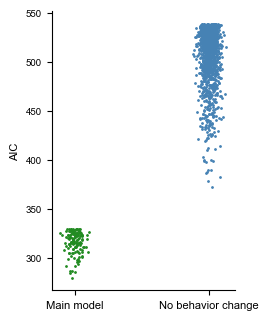

In [76]:
# AIC comparision between model and alternative
fig = plt.figure(figsize=(x_size/3, y_size/3))

ax = fig.add_subplot(1,1,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

AIC_model = 2*5 - 2*LL_model
AIC_no_bc = 2*3 - 2*LL_no_bc

ax.scatter(np.zeros(len(AIC_model))+ np.random.normal(0,0.04,len(AIC_model)), AIC_model, color = "forestgreen", s = 1)
ax.scatter(np.ones(len(AIC_no_bc))++ np.random.normal(0,0.04,len(AIC_no_bc)), AIC_no_bc, color = "steelblue", s = 1)

ax.set_ylabel("AIC", **labelfont)
ax.set_xticks([0,1])
ax.set_xticklabels(["Main model", "No behavior change"], **labelfont)
plt.savefig(path_to_plots+"/AIC_no_bc.pdf", bbox_inches='tight')

## Other supplementary figures

In [83]:
# compare to https://wwwnc.cdc.gov/eid/article/30/7/24-0092_article
# here definition: at risk = more than 5 anal partners within 12 months
# in our context: everyone with more 2 or more partners


# get immune status of population share with 8 or more contacts
repo = path_to_results+"model/run3"
LL_range_D, LL_range_I, LL_range_lambda, LL_range_R, LL_range_R_lambda, LL_range_M, LL_range_mean_degree_I, LL_range_I_degrees = apply_ll_large(repo, 3, LL_berlin)
print(len(LL_range_D))


vaccinated_2 = np.zeros(len(LL_range_D))
infected_2 = np.zeros(len(LL_range_D))

s = 0
for i in LL_range_D.index:
    print(s)
    try:
        agent_info = pd.read_csv(repo+"/has_result_agent_info_"+str(i))
    except:
        print(i)

    for k in range(len(agent_info)):
        if agent_info.iloc[k]["mu"] >= 2:
            # check if infected
            if agent_info.iloc[k]["infection_source"] != 0:
                infected_2[s] += 1
            # check if vaccinated
            elif agent_info.iloc[k]["vaccination_status"]== 1:
                vaccinated_2[s] += 1
    s += 1

100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
143
143
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142


25447
0.25400716311236216
Means:
[32.34032835557573, 25.400716311236213, 42.258955333188055]
100.0
95% PI
31.08441073603961 33.665658034345896
22.451565999921407 27.85534640625614
40.98322002593626 43.99005776712382
Immunized:
57.74104466681195
56.00994223287618
59.01677997406374


/var/folders/gp/6wr8fvm17zn8xfc8dwhg0md40000gn/T/ipykernel_39181/1888763161.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)


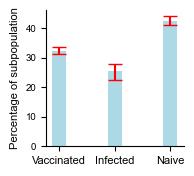

In [84]:
fig = plt.figure(figsize=(x_size/4, x_size/4))

# left panel
# infection, vaccination distribution
ax = fig.add_subplot(1,1,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

values_all, counts_all = np.unique(mu, return_counts=True)
total_2 = np.sum(counts_all) - counts_all[0]
print(total_2)

print(np.mean(infected_2/total_2))
# high contacts
naive = total_2 - vaccinated_2 - infected_2

a = [0, 0.2, 0.4]
b = [np.mean(vaccinated_2*100/total_2), np.mean(infected_2*100/total_2), np.mean(naive*100/total_2)]
width = 0.05

y_errormin = [np.mean(vaccinated_2*100/total_2) - np.quantile(vaccinated_2*100/total_2, 0.025),np.mean(infected_2*100/total_2) - np.quantile(infected_2*100/total_2, 0.025), np.mean(naive*100/total_2) - np.quantile(naive*100/total_2, 0.025)]
y_errormax = [-np.mean(vaccinated_2*100/total_2) + np.quantile(vaccinated_2*100/total_2, 0.975),-np.mean(infected_2*100/total_2) + np.quantile(infected_2*100/total_2, 0.975), -np.mean(naive*100/total_2) + np.quantile(naive*100/total_2, 0.975)]
c = [y_errormin, y_errormax]
ax.bar(a, b, width = width, color = "lightblue", label = "Many contacts\n ("+str(round(total_2/N*100,1))+"%)")
ax.errorbar(a, b, yerr=c, fmt='.k', color="r",  capsize=5, capthick=1, ms = 0)
print("Means:")
print(b)
print(np.sum(b))
print("95% PI")
print(b[0]-y_errormin[0], b[0]+y_errormax[0])
print(b[1]-y_errormin[1], b[1]+y_errormax[1])
print(b[2]-y_errormin[2], b[2]+y_errormax[2])

print("Immunized:")
print(np.mean((vaccinated_2+infected_2)*100/total_2))
print(np.quantile((vaccinated_2+infected_2)*100/total_2, 0.025))
print(np.quantile((vaccinated_2+infected_2)*100/total_2, 0.975))

ax.set_xticks(a)
ax.set_xticklabels(["Vaccinated", "Infected", "Naive"], **labelfont)
ax.set_ylabel("Percentage of subpopulation", **labelfont)

plt.savefig(path_to_plots+"/s_high_risk.pdf", bbox_inches='tight')
